# Airline Flight Delay Analysis - Stage 1: Data Preparation & Exploratory Analysis

---

## Overview

The **Air Travel Delay dataset**, which comprises approximately 101,000 records of commercial airline flights from January 2008, is used in this notebook to present Stage 1 of a two-stage data science project. The goal of the analysis is to create a clear, comprehensible dataset for Stage 2 predictive modelling.



In [301]:
# ============================================================
# Airline Flight Delay Analysis - Stage 1
# ============================================================
# Dataset   : airline_delay.csv
# Records   : 101,000 flights | January 2008
# Target Variable : ArrDelay (arrival delay in minutes), using regression
# Stage 1         : Understand, clean, and prepare ArrDelay and its related features
# Stage 2         : Build a Regression model to predict ArrDelay for unseen flights
# ============================================================

# Importing Necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Setting up a consist style for all the plots in the program
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

# Loading the Dataset
df = pd.read_csv('airline_delay.csv')

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [302]:
# Getting some intial information
df.head()

,Year,Month,DayofMonth,DayOfWeek,DepTime,CRSDepTime,ArrTime,CRSArrTime,UniqueCarrier,FlightNum,...,TaxiIn,TaxiOut,Cancelled,CancellationCode,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
0,2008,1,31,4,611.0,610,725.0,720,WN,548,...,3.0,13.0,0,NaN,0,NaN,NaN,NaN,NaN,NaN
1,2008,1,18,5,1946.0,1935,2007.0,2010,WN,3770,...,6.0,7.0,0,NaN,0,NaN,NaN,NaN,NaN,NaN
2,2008,1,17,4,1018.0,1020,1102.0,1110,WN,12,...,3.0,9.0,0,NaN,0,NaN,NaN,NaN,NaN,NaN
3,2008,1,10,4,2057.0,2055,2304.0,2300,WN,74,...,5.0,14.0,0,NaN,0,NaN,NaN,NaN,NaN,NaN
4,2008,1,15,2,1825.0,18:25,2031.0,2050,WN,2530,...,5.0,13.0,0,NaN,0,NaN,NaN,NaN,NaN,NaN


In [303]:
df.info()

df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 101000 entries, 0 to 100999
Data columns (total 29 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Year               101000 non-null  int64  
 1   Month              101000 non-null  int64  
 2   DayofMonth         101000 non-null  int64  
 3   DayOfWeek          101000 non-null  int64  
 4   DepTime            99873 non-null   str    
 5   CRSDepTime         101000 non-null  str    
 6   ArrTime            99719 non-null   str    
 7   CRSArrTime         101000 non-null  str    
 8   UniqueCarrier      101000 non-null  str    
 9   FlightNum          101000 non-null  int64  
 10  TailNum            96854 non-null   str    
 11  ActualElapsedTime  99690 non-null   str    
 12  CRSElapsedTime     101000 non-null  str    
 13  AirTime            99690 non-null   str    
 14  ArrDelay           97700 non-null   float64
 15  DepDelay           97850 non-null   float64
 16  Origin       

,Year,Month,DayofMonth,DayOfWeek,FlightNum,ArrDelay,DepDelay,TaxiIn,TaxiOut,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
count,101000.0,101000.0,101000.000000,101000.000000,101000.000000,97700.000000,97850.000000,98689.000000,98847.000000,19823.000000,19823.000000,19823.000000,19823.000000,19823.000000
mean,2008.0,1.0,17.090366,3.890554,1510.900891,5.711648,10.366050,4.768566,10.926826,9.561671,2.043737,8.356001,0.114665,29.311456
std,0.0,0.0,8.357797,1.952622,1185.510606,30.913736,28.335769,2.980770,5.988951,21.798833,13.859033,18.805939,1.827800,39.734333
min,2008.0,1.0,1.000000,1.000000,1.000000,-57.000000,-44.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2008.0,1.0,10.000000,2.000000,502.000000,-9.000000,-2.000000,3.000000,8.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,2008.0,1.0,17.000000,4.000000,1320.000000,-2.000000,1.000000,4.000000,9.000000,1.000000,0.000000,0.000000,0.000000,18.000000
75%,2008.0,1.0,24.000000,5.000000,2362.000000,10.000000,10.000000,5.000000,12.000000,11.000000,0.000000,10.000000,0.000000,37.000000
max,2008.0,1.0,31.000000,7.000000,7676.000000,500.000000,516.000000,213.000000,150.000000,431.000000,267.000000,366.000000,88.000000,434.000000


In [304]:
df.isnull().sum()


Year                     0
Month                    0
DayofMonth               0
DayOfWeek                0
DepTime               1127
CRSDepTime               0
ArrTime               1281
CRSArrTime               0
UniqueCarrier            0
FlightNum                0
TailNum               4146
ActualElapsedTime     1310
CRSElapsedTime           0
AirTime               1310
ArrDelay              3300
DepDelay              3150
Origin                   0
Dest                     0
Distance                 0
TaxiIn                2311
TaxiOut               2153
Cancelled                0
CancellationCode     99364
Diverted                 0
CarrierDelay         81177
WeatherDelay         81177
NASDelay             81177
SecurityDelay        81177
LateAircraftDelay    81177
dtype: int64

In [305]:
df.duplicated().sum()

np.int64(1000)

## Step 1 - Problem Definition

### Business Problem

One of the most costly and disruptive problems in business aviation is flight delays. Each year, flight delays incur billions of dollars in lost revenue in the Various countires, which is attributed to fuel costs, crew costs, gate costs, and passenger compensation. Travelers face significant frustration and wasted productivity as a result of flight delays

This project addresses the following **research question**:

> **Can we predict the arrival delay (in minutes) of a commercial flight, given information available at or before the time of departure?**

This can be described as a **regression problem**, and the target variable whcich seems the best fitting in this case is `ArrDelay`, which is defined as the time that a flight is delayed compared to its scheduled time to arrive. Early arrival is indicated by negative values.

Predictive features that are known at or shortly after departure include departure delay, scheduled departure time, carrier, origin and destination airports, day of the week, distance, and taxi out time.

---

### Stakeholders & Benefits

| Stakeholder | How They Benefit |
|---|---|
| **Airlines (e.g., Southwest, ExpressJet)** | Can proactively manage crew scheduling, gate reassignments, and fuel planning if a delay is predicted early. Reduces cascading delays within the network. |
| **Airport Operations Teams** | Can better allocate ground crew, gates, and baggage handling resources based on predicted arrival times. |
| **Passengers** | an receive earlier or more accurate notifications of a flight's delay, allowing them to re-book connections, etc. |
| **Air Traffic Control (ATC / NAS)** | Can anticipate congestion patterns that may occur at the destination airports. |
| **Travel Platforms (e.g., Google Flights, booking apps)** |Can surface flight delay risk estimates to the user at the time of booking or check-in. |

---

### Why Regression over Classification?

While a binary classification approach (delayed vs. not delayed) is simpler, it can discard critical information. A flight arriving 16 minutes late and another arriving 4 hours late are operationally very different situations, yet a classifier treats them identically. By predicting the exact delay in minutes, the model produces actionable outputs that are directly useful for operational decision-making.

## Step 2 - Data Description

### 2.1 Dataset Shape

The first step in understanding the dataset is knowing its size, like how many records (instances) it contains and how many attributes (columns) describe each record.

In [306]:
# 2.1 Getting the Dataset Shape

rows, cols = df.shape

print("=" * 40)
print("DATASET SHAPE SUMMARY")
print("=" * 40)
print(f"Total Instances (Rows) : {rows:,}")
print(f"Total Attributes (Cols): {cols}")
print("=" * 40)

DATASET SHAPE SUMMARY
Total Instances (Rows) : 101,000
Total Attributes (Cols): 29


### 2.2 Attribute Data Types

Understanding the data type of each attribute is critical before any analysis or modelling. Incorrect data types can cause some errors in calculations, misleading statistics, and can lead to a failed model training.

Below we are displaying the data type of every column and flag any columns that are stored in the wrong type. For example, numerical columns like `Distance`, `AirTime`, and time columns are incorrectly stored as strings (`object`) instead of numbers. These will be corrected in Step 3 (Data Cleaning).

In [307]:
# 2.2 Attribute Data Types

# Columns that should be numeric based on what they represent
expected_numeric = [
    'DepTime', 'CRSDepTime', 'ArrTime', 'CRSArrTime',
    'ActualElapsedTime', 'CRSElapsedTime', 'AirTime', 'Distance',
    'Cancelled', 'Diverted'
]


type_flags = []

for col in df.columns:
    if col in expected_numeric:
        if df[col].dtype not in ['int64', 'float64']:
            type_flags.append('Incorrect - Should be Numeric')
        else:
            type_flags.append('Correct')
    else:
        type_flags.append('Correct')

# Summary DataFrame
type_summary = pd.DataFrame({
    'Column'      : df.columns,
    'Stored Type' : df.dtypes.values,
    'Type Flag'   : type_flags
})

# Separate correct and incorrect for clarity
incorrect = type_summary[type_summary['Type Flag'] == 'Incorrect - Should be Numeric']
correct = type_summary[type_summary['Type Flag'] == 'Correct']

# To display the Summary Table 
print("ATTRIBUTE DATA TYPES - FULL SUMMARY")
display(type_summary.style.set_properties(**{
    'text-align': 'left',
    'padding'   : '6px 15px'
}).set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'left'), ('padding', '6px 15px'), ('background-color', "#000000")]}
]).apply(lambda x: [
    'background-color: #555555' if v == 'Incorrect - Should be Numeric' else '' for v in x
], subset=['Type Flag']))

# Summary Counts 
print(f"\nTotal Attributes  : {len(type_summary)}")
print(f"Correct Types     : {len(correct)}")
print(f"Incorrect Types   : {len(incorrect)}")

# To display Incorrect Columns Only 
print("\nINCORRECT COLUMNS - To be fixed in Step 3")
display(incorrect.style.set_properties(**{
    'text-align'      : 'left',
    'padding'         : '6px 15px',
    'background-color': "#000000"
}).set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'left'), ('padding', '6px 15px'), ('background-color', "#616161")]}
]))

ATTRIBUTE DATA TYPES - FULL SUMMARY


,Column,Stored Type,Type Flag
0,Year,int64,Correct
1,Month,int64,Correct
2,DayofMonth,int64,Correct
3,DayOfWeek,int64,Correct
4,DepTime,str,Incorrect - Should be Numeric
5,CRSDepTime,str,Incorrect - Should be Numeric
6,ArrTime,str,Incorrect - Should be Numeric
7,CRSArrTime,str,Incorrect - Should be Numeric
8,UniqueCarrier,str,Correct
9,FlightNum,int64,Correct



Total Attributes  : 29
Correct Types     : 19
Incorrect Types   : 10

INCORRECT COLUMNS - To be fixed in Step 3


,Column,Stored Type,Type Flag
4,DepTime,str,Incorrect - Should be Numeric
5,CRSDepTime,str,Incorrect - Should be Numeric
6,ArrTime,str,Incorrect - Should be Numeric
7,CRSArrTime,str,Incorrect - Should be Numeric
11,ActualElapsedTime,str,Incorrect - Should be Numeric
12,CRSElapsedTime,str,Incorrect - Should be Numeric
13,AirTime,str,Incorrect - Should be Numeric
18,Distance,str,Incorrect - Should be Numeric
21,Cancelled,str,Incorrect - Should be Numeric
23,Diverted,str,Incorrect - Should be Numeric


### 2.3 Missing Values

Identifying missing values is a crucial step in data description. Missing data can significantly impact the quality of analysis and model performance if not handled properly.

Below we calculated the count and percentage of missing values for every column, display it as a table, and visualise the most affected columns in a bar chart. Columns with missing values will be addressed in Step 3 (Data Cleaning).

MISSING VALUES - FULL SUMMARY


,Column,Missing Count,Missing %,Has Missing
0,CancellationCode,99364,98.380000,Yes
1,NASDelay,81177,80.370000,Yes
2,LateAircraftDelay,81177,80.370000,Yes
3,WeatherDelay,81177,80.370000,Yes
4,CarrierDelay,81177,80.370000,Yes
5,SecurityDelay,81177,80.370000,Yes
6,TailNum,4146,4.100000,Yes
7,ArrDelay,3300,3.270000,Yes
8,DepDelay,3150,3.120000,Yes
9,TaxiIn,2311,2.290000,Yes



Total Columns with Missing Values : 15
Total Complete Columns            : 14


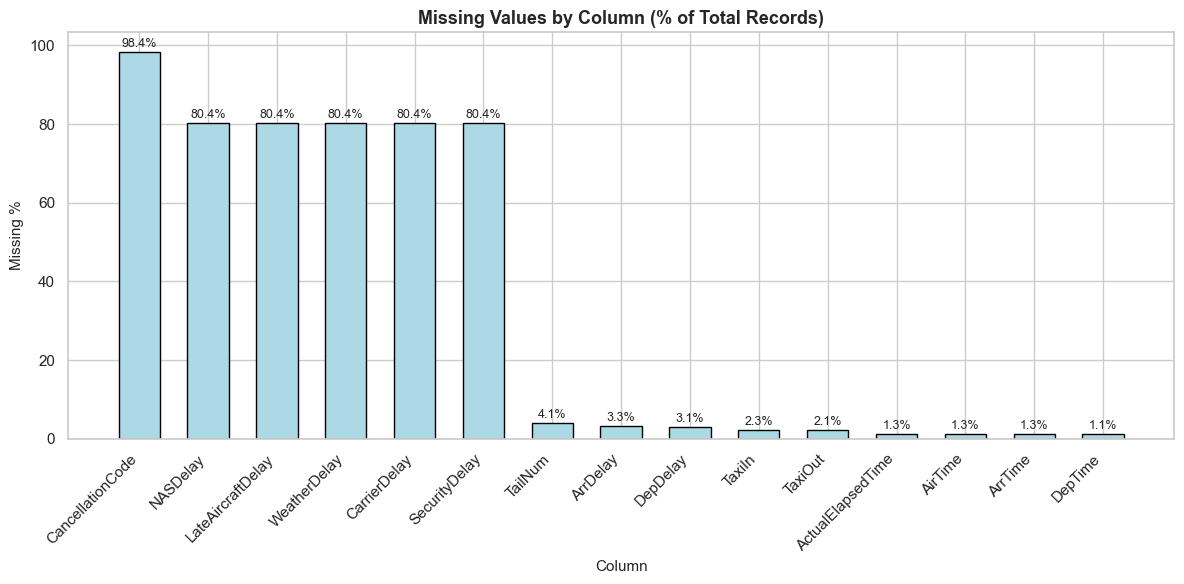

In [308]:
# 2.3 Missing Values

# Calculating the missing count and percentage for each column
missing_counts = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

# Summary DataFrame
missing_summary = pd.DataFrame({
    'Column'         : df.columns,
    'Missing Count'  : missing_counts.values,
    'Missing %'      : missing_percent.round(2).values,
    'Has Missing'    : ['Yes' if x > 0 else 'No' for x in missing_counts.values]
})

# Sort by missing count descending
missing_summary = missing_summary.sort_values('Missing Count', ascending=False).reset_index(drop=True)

# To display the Full Missing Values Table
print("MISSING VALUES - FULL SUMMARY")
display(missing_summary.style.set_properties(**{
    'text-align' : 'left',
    'padding'    : '6px 15px'
}).set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'left'), ('padding', '6px 15px'), ('background-color', "#000000")]}
]).apply(lambda x: [
    'background-color: #555555' if v == 'Yes' else '' for v in x
], subset=['Has Missing']))

# Summary Counts 
total_missing_cols = (missing_summary['Has Missing'] == 'Yes').sum()
total_complete_cols = (missing_summary['Has Missing'] == 'No').sum()

print(f"\nTotal Columns with Missing Values : {total_missing_cols}")
print(f"Total Complete Columns            : {total_complete_cols}")

# Bar Chart: Only columns with missing values
missing_only = missing_summary[missing_summary['Missing Count'] > 0]

plt.figure(figsize=(12, 6))
bars = plt.bar(
    missing_only['Column'],
    missing_only['Missing %'],
    color='lightblue',
    edgecolor='black',
    width=0.6
)

# Adding percentage labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.title('Missing Values by Column (% of Total Records)', fontsize=13, fontweight='bold')
plt.xlabel('Column', fontsize=11)
plt.ylabel('Missing %', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 2.4 Unique Values in Categorical Features

Categorical features are columns that represent discrete groups or labels rather than continuous numbers. Understanding the unique values in these columns helps us identify the range of categories, spot any inconsistencies (such as mixed case or extra spaces), and understand which features may be useful for modelling.

We are separating categorical columns into:
- **Low cardinality** - few unique values (means we are listing the actual values)
- **High cardinality** - many unique values (we are only showing the count, as listing all would be impractical)

In [309]:
# 2.4 Unique Values in Categorical Features

# Identify categorical columns (object/string type)
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# To build unique value summary
unique_summary_data = []

for col in categorical_cols:
    n_unique = df[col].nunique()
    unique_summary_data.append({
        'Column'        : col,
        'Unique Count'  : n_unique,
        'Cardinality'   : 'Low (<=15)' if n_unique <= 15 else 'High (>15)'
    })

unique_summary = pd.DataFrame(unique_summary_data)
unique_summary = unique_summary.sort_values('Unique Count').reset_index(drop=True)

# To display Unique Value Summary Table
print("CATEGORICAL FEATURES - UNIQUE VALUE SUMMARY")
display(unique_summary.style.set_properties(**{
    'text-align' : 'left',
    'padding'    : '6px 15px'
}).set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'left'), ('padding', '6px 15px'), ('background-color', "#000000")]}
]).apply(lambda x: [
    'background-color: #555555' if v == 'Low (<=15)' else '' for v in x
], subset=['Cardinality']))

print(f"\nTotal Categorical Columns : {len(categorical_cols)}")
print(f"Low Cardinality  (<=15)   : {(unique_summary['Cardinality'] == 'Low (<=15)').sum()}")
print(f"High Cardinality (>15)    : {(unique_summary['Cardinality'] == 'High (>15)').sum()}")

# Listing Actual Values for Low Cardinality Columnn
print("\nACTUAL VALUES - LOW CARDINALITY COLUMNS")
print("-" * 70)

low_cardinality_cols = unique_summary[unique_summary['Cardinality'] == 'Low (<=15)']['Column'].tolist()

for col in low_cardinality_cols:
    actual_values = df[col].dropna().unique().tolist()
    print(f"\n  {col} ({len(actual_values)} unique values):")
    print(f"  {actual_values}")

print("-" * 70)

CATEGORICAL FEATURES - UNIQUE VALUE SUMMARY


,Column,Unique Count,Cardinality
0,CancellationCode,3,Low (<=15)
1,Cancelled,6,Low (<=15)
2,Diverted,6,Low (<=15)
3,UniqueCarrier,10,Low (<=15)
4,CRSElapsedTime,273,High (>15)
5,Origin,308,High (>15)
6,Dest,312,High (>15)
7,AirTime,579,High (>15)
8,ActualElapsedTime,581,High (>15)
9,TailNum,622,High (>15)



Total Categorical Columns : 15
Low Cardinality  (<=15)   : 4
High Cardinality (>15)    : 11

ACTUAL VALUES - LOW CARDINALITY COLUMNS
----------------------------------------------------------------------

  CancellationCode (3 unique values):
  ['A', 'B', 'C']

  Cancelled (6 unique values):
  ['0', '1', 'TRUE', 'N', 'FALSE', 'Y']

  Diverted (6 unique values):
  ['0', '1', 'N', 'Y', 'TRUE', 'FALSE']

  UniqueCarrier (10 unique values):
  ['WN', 'XE', 'W', 'WN ', ' WN', 'wn', 'X', 'xe', 'XE ', ' XE']
----------------------------------------------------------------------


### 2.5 Summary Statistics

Summary statistics provide a quick numerical overview of all numerical columns in the dataset. This helps us understand the central tendency, spread, and range of each feature and also helps identify potential anomalies such as negative values or extreme outliers that will need to be addressed in Step 3 (Data Cleaning).

Key statistics displayed:
- **Count** - number of non-missing values
- **Mean** - average value
- **Std** - standard deviation (spread of values)
- **Min / Max** - smallest and largest values
- **25%, 50%, 75%** - quartiles showing the distribution shape

In [310]:
# 2.5 Summary Statistics

# Selecting only numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Generating summary statistics
stats_summary = df[numeric_cols].describe().T.round(2)

# Renaming index to Column for clarity
stats_summary.index.name = 'Column'
stats_summary = stats_summary.reset_index()

# To display Summary Statistics Table
print("SUMMARY STATISTICS - NUMERICAL COLUMNS")
display(stats_summary.style.set_properties(**{
    'text-align' : 'left',
    'padding'    : '6px 15px'
}).set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'left'), ('padding', '6px 15px'), ('background-color', "#000000")]}
]))

# Flag Potential Anomalies
print("\nPOTENTIAL ANOMALIES DETECTED")
print("-" * 70)

anomalies = []

for col in numeric_cols:
    min_val = df[col].min()
    if min_val < 0:
        anomalies.append({
            'Column'   : col,
            'Issue'    : 'Negative Values',
            'Min Value': min_val
        })

if len(anomalies) > 0:
    anomaly_df = pd.DataFrame(anomalies)
    display(anomaly_df.style.set_properties(**{
        'text-align'      : 'left',
        'padding'         : '6px 15px',
        'background-color': "#564444"
    }).set_table_styles([
        {'selector': 'th', 'props': [('text-align', 'left'), ('padding', '6px 15px'), ('background-color', "#000000")]}
    ]))
else:
    print("No anomalies detected.")

print("-" * 70)
print("\nNote: Negative values in Distance and Delay columns are data quality issues to be addressed in Step 3.")

SUMMARY STATISTICS - NUMERICAL COLUMNS


,Column,count,mean,std,min,25%,50%,75%,max
0,Year,101000.000000,2008.000000,0.000000,2008.000000,2008.000000,2008.000000,2008.000000,2008.000000
1,Month,101000.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2,DayofMonth,101000.000000,17.090000,8.360000,1.000000,10.000000,17.000000,24.000000,31.000000
3,DayOfWeek,101000.000000,3.890000,1.950000,1.000000,2.000000,4.000000,5.000000,7.000000
4,FlightNum,101000.000000,1510.900000,1185.510000,1.000000,502.000000,1320.000000,2362.000000,7676.000000
5,ArrDelay,97700.000000,5.710000,30.910000,-57.000000,-9.000000,-2.000000,10.000000,500.000000
6,DepDelay,97850.000000,10.370000,28.340000,-44.000000,-2.000000,1.000000,10.000000,516.000000
7,TaxiIn,98689.000000,4.770000,2.980000,1.000000,3.000000,4.000000,5.000000,213.000000
8,TaxiOut,98847.000000,10.930000,5.990000,1.000000,8.000000,9.000000,12.000000,150.000000
9,CarrierDelay,19823.000000,9.560000,21.800000,0.000000,0.000000,1.000000,11.000000,431.000000



POTENTIAL ANOMALIES DETECTED
----------------------------------------------------------------------


,Column,Issue,Min Value
0,ArrDelay,Negative Values,-57.000000
1,DepDelay,Negative Values,-44.000000


----------------------------------------------------------------------

Note: Negative values in Distance and Delay columns are data quality issues to be addressed in Step 3.


## Step 3 - Data Cleaning and Processing

Data cleaning is the process of detecting and correcting errors, inconsistencies, and inaccuracies in the dataset to ensure it is accurate, consistent, and ready for modelling.

In Step 2, we identified the following data quality issues:
- 10 columns stored in incorrect data types (strings instead of numbers)
- Inconsistent value encoding in Cancelled, Diverted, and UniqueCarrier
- Missing values across 15 columns
- Redundant and irrelevant columns that add no predictive value

We have addressed each of these issues systematically in this step, providing a clear justification for every decision made.

---

### 3.1 Fix Incorrect Data Types

In Step 2 we identified 10 columns that are stored as strings but should be numeric. These columns contain numbers such as times (e.g. 610 meaning 6:10am), distances in miles, and binary flags (0 or 1). Keeping them as strings means we cannot perform any mathematical operations, calculate statistics, or use them in a model.

We used `pd.to_numeric()` with `errors='coerce'` to convert each column. The `errors='coerce'` argument means that if a value cannot be converted to a number (e.g. a stray text character), it will be replaced with NaN rather than throwing an error. This is the safest approach we could think of as it handles any hidden dirty values automatically without crashing the conversion.

In [311]:
# 3.1 Fix Incorrect Data Types

# Columns to convert from string to numeric
columns_to_convert = [
    'DepTime', 'CRSDepTime', 'ArrTime', 'CRSArrTime',
    'ActualElapsedTime', 'CRSElapsedTime', 'AirTime', 'Distance',
    'Cancelled', 'Diverted'
]

# Store original dtypes for comparison
original_dtypes = df[columns_to_convert].dtypes.copy()

# Convert each column to numeric
for col in columns_to_convert:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# To build before and after comparison table
conversion_results = []

for col in columns_to_convert:
    conversion_results.append({
        'Column'       : col,
        'Type Before'  : str(original_dtypes[col]),
        'Type After'   : str(df[col].dtype),
        'Converted'    : 'Yes' if str(original_dtypes[col]) != str(df[col].dtype) else 'No'
    })

conversion_df = pd.DataFrame(conversion_results)

# To display Conversion Results Table
print("DATA TYPE CONVERSION RESULTS")
display(conversion_df.style.set_properties(**{
    'text-align' : 'left',
    'padding'    : '6px 15px'
}).set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'left'), ('padding', '6px 15px'), ('background-color', "#000000")]}
]).apply(lambda x: [
    'background-color: #555555' if v == 'Yes' else '' for v in x
], subset=['Converted']))

# Verify conversion count
converted_count = (conversion_df['Converted'] == 'Yes').sum()
print(f"\nTotal Columns Successfully Converted : {converted_count} / {len(columns_to_convert)}")

# To show updated dtypes of full dataframe
print("\nUPDATED DATAFRAME - ALL COLUMN TYPES")
updated_types = pd.DataFrame({
    'Column'     : df.columns,
    'Data Type'  : df.dtypes.values
})

display(updated_types.style.set_properties(**{
    'text-align' : 'left',
    'padding'    : '6px 15px'
}).set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'left'), ('padding', '6px 15px'), ('background-color', "#555555")]}
]))

DATA TYPE CONVERSION RESULTS


,Column,Type Before,Type After,Converted
0,DepTime,str,float64,Yes
1,CRSDepTime,str,float64,Yes
2,ArrTime,str,float64,Yes
3,CRSArrTime,str,float64,Yes
4,ActualElapsedTime,str,float64,Yes
5,CRSElapsedTime,str,float64,Yes
6,AirTime,str,float64,Yes
7,Distance,str,float64,Yes
8,Cancelled,str,float64,Yes
9,Diverted,str,float64,Yes



Total Columns Successfully Converted : 10 / 10

UPDATED DATAFRAME - ALL COLUMN TYPES


,Column,Data Type
0,Year,int64
1,Month,int64
2,DayofMonth,int64
3,DayOfWeek,int64
4,DepTime,float64
5,CRSDepTime,float64
6,ArrTime,float64
7,CRSArrTime,float64
8,UniqueCarrier,str
9,FlightNum,int64


### 3.2 Standardising Inconsistent Values

In Step 2 we identified three columns with inconsistent value encoding:

- **Cancelled** - contains '0', '1', 'TRUE', 'FALSE', 'Y', 'N' all meaning the same two things
- **Diverted** - same mixed encoding issue as Cancelled
- **UniqueCarrier** - contains 'WN', 'wn', ' WN', 'WN ' all referring to Southwest Airlines, and 'XE', 'xe', ' XE', 'XE ' all referring to ExpressJet

These inconsistencies probably arised from how the data was collected and merged from different sources. We came to a decision that if left uncleaned, the same category would be treated as multiple different categories by a model, leading to incorrect analysis and poor model performance.

**Cleaning Strategy used:**
- For Cancelled and Diverted: since Step 3.1 already converted these to numeric (0.0/1.0), we simply converted them to clean integers (0 or 1)
- For UniqueCarrier: stripped leading/trailing spaces and converted to uppercase, then mapped partial codes 'W' and 'X' to their correct carriers 'WN' and 'XE'

In [312]:
# 3.2 Standardising Inconsistent Values 

# 3.2.1 Fixing Cancelled and Diverted columns

# Note: we already converted these columns to numeric (0.0/1.0) in Step 3.1
# We are now simply converting them to clean integers (0 or 1)

# Storing before values
cancelled_before = df['Cancelled'].unique().tolist()
diverted_before = df['Diverted'].unique().tolist()

# Converting to integer 0 or 1
df['Cancelled'] = df['Cancelled'].fillna(0).astype(int)
df['Diverted'] = df['Diverted'].fillna(0).astype(int)

# To show before and after
print("CANCELLED COLUMN - STANDARDISATION")
print("-" * 45)
print(f"Before : {cancelled_before}")
print(f"After  : {sorted(df['Cancelled'].unique().tolist())}")
print(f"Type   : {df['Cancelled'].dtype}")

print("\nDIVERTED COLUMN - STANDARDISATION")
print("-" * 45)
print(f"Before : {diverted_before}")
print(f"After  : {sorted(df['Diverted'].unique().tolist())}")
print(f"Type   : {df['Diverted'].dtype}")

CANCELLED COLUMN - STANDARDISATION
---------------------------------------------
Before : [0.0, 1.0, nan]
After  : [0, 1]
Type   : int64

DIVERTED COLUMN - STANDARDISATION
---------------------------------------------
Before : [0.0, 1.0, nan]
After  : [0, 1]
Type   : int64


In [313]:
# 3.2.2 Fixing UniqueCarrier column

# Storing original unique values
carrier_before = df['UniqueCarrier'].unique().tolist()

# Step 1: Stripping whitespace and converting to uppercase
df['UniqueCarrier'] = df['UniqueCarrier'].str.strip().str.upper()

# Step 2: Mapping partial/corrupted codes to correct carrier codes
# 'W' is a corrupted version of 'WN' (Southwest Airlines)
# 'X' is a corrupted version of 'XE' (ExpressJet)
carrier_mapping = {
    'W' : 'WN',
    'X' : 'XE'
}

df['UniqueCarrier'] = df['UniqueCarrier'].replace(carrier_mapping)

# Storing after unique values
carrier_after = df['UniqueCarrier'].unique().tolist()

print("\nUNIQUECARRIER COLUMN - STANDARDISATION")
print("-" * 45)
print(f"Before ({len(carrier_before)} unique) : {carrier_before}")
print(f"After  ({len(carrier_after)} unique)  : {carrier_after}")
print(f"Type : {df['UniqueCarrier'].dtype}")


UNIQUECARRIER COLUMN - STANDARDISATION
---------------------------------------------
Before (10 unique) : ['WN', 'XE', 'W', 'WN ', ' WN', 'wn', 'X', 'xe', 'XE ', ' XE']
After  (2 unique)  : ['WN', 'XE']
Type : str


In [314]:
# 3.2.3 Creating a Standardisation Summary Table of what we did

standardise_summary = pd.DataFrame({
    'Column'        : ['Cancelled', 'Diverted', 'UniqueCarrier'],
    'Issue'         : [
        'Numeric float (0.0/1.0) needed clean integer conversion',
        'Numeric float (0.0/1.0) needed clean integer conversion',
        'Mixed case, spaces, and partial carrier codes'
    ],
    'Fix Applied'   : [
        'Filled NaN with 0, converted to integer',
        'Filled NaN with 0, converted to integer',
        'Stripped spaces, uppercased, mapped W→WN and X→XE'
    ],
    'Unique Before' : [len(cancelled_before), len(diverted_before), len(carrier_before)],
    'Unique After'  : [
        df['Cancelled'].nunique(),
        df['Diverted'].nunique(),
        df['UniqueCarrier'].nunique()
    ]
})

print("\nSTANDARDISATION SUMMARY")
display(standardise_summary.style.set_properties(**{
    'text-align' : 'left',
    'padding'    : '6px 15px'
}).set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'left'), ('padding', '6px 15px'), ('background-color', "#000000")]}
]))


STANDARDISATION SUMMARY


,Column,Issue,Fix Applied,Unique Before,Unique After
0,Cancelled,Numeric float (0.0/1.0) needed clean integer conversion,"Filled NaN with 0, converted to integer",3,2
1,Diverted,Numeric float (0.0/1.0) needed clean integer conversion,"Filled NaN with 0, converted to integer",3,2
2,UniqueCarrier,"Mixed case, spaces, and partial carrier codes","Stripped spaces, uppercased, mapped W→WN and X→XE",10,2


### 3.3 Handling Invalid Entries

We identified that the `Distance` column contains negative values in the dataset. After further inspection we also found negative values in `ActualElapsedTime`, `CRSElapsedTime`and `AirTime` (found  in the cell below).

All of these are physically impossible:
- A flight cannot have a negative distance
- A flight cannot have a negative elapsed time or air time

These are clearly data entry or recording errors and must be removed.

**Cleaning Strategy:**
We decided to remove all rows where any of these four columns contain a negative value.
Our justification:
- The total rows affected is a very small fraction of the 101,000 total rows
- We have no reliable way to recover the correct values for these entries
- Keeping physically impossible values would corrupt distance and time based analysis
- The dataset remains large enough after removal to train a reliable model

In [315]:
# 3.3 Handling Invalid Entries 

# 3.3.1 Identifying All Invalid Entries First

# Columns that should never have negative values
non_negative_cols = [
    'Distance', 'ActualElapsedTime', 'CRSElapsedTime', 'AirTime'
]

total_before = len(df)

print("INVALID ENTRIES BEFORE CLEANING")
print("-" * 50)

invalid_summary = []

for col in non_negative_cols:
    neg_count = (df[col] < 0).sum()
    invalid_summary.append({
        'Column'          : col,
        'Negative Count'  : neg_count,
        'Percentage'      : round((neg_count / total_before) * 100, 3)
    })

invalid_summary_df = pd.DataFrame(invalid_summary)

display(invalid_summary_df.style.set_properties(**{
    'text-align' : 'left',
    'padding'    : '6px 15px'
}).set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'left'), ('padding', '6px 15px'), ('background-color', "#000000")]}
]).apply(lambda x: [
    'background-color: #555555' if v > 0 else 'background-color: #BB9292' for v in x
], subset=['Negative Count']))


INVALID ENTRIES BEFORE CLEANING
--------------------------------------------------


,Column,Negative Count,Percentage
0,Distance,248,0.246000
1,ActualElapsedTime,234,0.232000
2,CRSElapsedTime,273,0.270000
3,AirTime,256,0.253000


In [316]:

# 3.3.2 Showing Sample of Invalid Rows

# Identifying all rows with any negative value in these columns
invalid_mask = (
    (df['Distance']          < 0) |
    (df['ActualElapsedTime'] < 0) |
    (df['CRSElapsedTime']    < 0) |
    (df['AirTime']           < 0)
)

print(f"\nTotal Rows Before Cleaning     : {total_before:,}")
print(f"Total Invalid Rows to Remove   : {invalid_mask.sum():,}")
print(f"Percentage of Dataset          : {(invalid_mask.sum()/total_before)*100:.2f}%")

print("\nSAMPLE OF INVALID ROWS")
sample_invalid = df[invalid_mask][['Origin', 'Dest', 'Distance', 'ActualElapsedTime', 'CRSElapsedTime', 'AirTime']].head(10)
display(sample_invalid.style.set_properties(**{
    'text-align'      : 'left',
    'padding'         : '6px 15px',
    'background-color': "#000000"
}).set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'left'), ('padding', '6px 15px'), ('background-color', "#5c5c5c")]}
]))



Total Rows Before Cleaning     : 101,000
Total Invalid Rows to Remove   : 1,009
Percentage of Dataset          : 1.00%

SAMPLE OF INVALID ROWS


,Origin,Dest,Distance,ActualElapsedTime,CRSElapsedTime,AirTime
35,SNA,SMF,404.000000,-84.000000,85.000000,72.000000
202,SAN,OKC,1136.000000,138.000000,-155.000000,124.000000
241,MHT,PHL,-290.000000,92.000000,85.000000,69.000000
431,MDW,HOU,937.000000,147.000000,165.000000,-135.000000
459,IND,MDW,162.000000,55.000000,-55.000000,42.000000
503,TPA,PHX,1788.000000,277.000000,290.000000,-262.000000
598,STL,CLE,487.000000,89.000000,-90.000000,75.000000
624,MCO,BDL,-1050.000000,147.000000,155.000000,131.000000
643,SMF,LAX,-373.000000,113.000000,80.000000,60.000000
692,PIT,BWI,210.000000,-60.000000,70.000000,47.000000


In [317]:

# 3.3.3 Removeing Invalid Rows

df = df[~invalid_mask].reset_index(drop=True)

total_after = len(df)


In [318]:

# 3.3.4 Verifying the Clean done

print("\nINVALID VALUE CHECK AFTER CLEANING")
print("-" * 50)

verify_summary = []

for col in non_negative_cols:
    neg_count = (df[col] < 0).sum()
    verify_summary.append({
        'Column'         : col,
        'Negative Count' : neg_count,
        'Status'         : 'Clean' if neg_count == 0 else 'Still Has Invalid Values'
    })

verify_df = pd.DataFrame(verify_summary)

display(verify_df.style.set_properties(**{
    'text-align' : 'left',
    'padding'    : '6px 15px'
}).set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'left'), ('padding', '6px 15px'), ('background-color', "#000000")]}
]).apply(lambda x: [
    'background-color: #6C806E' if v == 'Clean' else 'background-color: #ffe6e6' for v in x
], subset=['Status']))


INVALID VALUE CHECK AFTER CLEANING
--------------------------------------------------


,Column,Negative Count,Status
0,Distance,0,Clean
1,ActualElapsedTime,0,Clean
2,CRSElapsedTime,0,Clean
3,AirTime,0,Clean


In [319]:

# 3.3.5 Summary

print("\nINVALID ENTRIES HANDLING - SUMMARY")
print("-" * 50)
print(f"Dataset size before            : {total_before:,}")
print(f"Total invalid rows removed     : {total_before - total_after:,}")
print(f"Dataset size after             : {total_after:,}")
print(f"Data retained                  : {(total_after/total_before)*100:.2f}%")


INVALID ENTRIES HANDLING - SUMMARY
--------------------------------------------------
Dataset size before            : 101,000
Total invalid rows removed     : 1,009
Dataset size after             : 99,991
Data retained                  : 99.00%


### 3.4 Handling Missing Values

Missing values must be handled carefully, the wrong strategy can introduce bias or destroy important information. After our previous cleaning steps, we have 19 columns with missing values remaining.

We were able to group them into three strategies, each with a purpose:

**Strategy 1 - Dropping the column entirely:**
- `CancellationCode` - 98.38% missing, only populated for cancelled flights (2% of data), no predictive value
- `TailNum` - aircraft registration number, no predictive value for arrival delay

**Strategy 2 - Filling with 0 (Padding):**
- `CarrierDelay`, `WeatherDelay`, `NASDelay`, `SecurityDelay`, `LateAircraftDelay` - 80.38% missing because these are only recorded when a delay occurred. Missing means no delay from that cause, so 0 is the correct fill value.

**Strategy 3 - Drop rows or fill with median:**
- `ArrDelay` - our target variable, cannot be filled or estimated. Dropping rows where it is missing.
- `ArrTime`, `DepTime` - actual times missing likely due to cancellation/diversion. Dropping these rows.
- All remaining columns with missing values, we are filling with median. Median is being preferred over mean as it is robust to outliers, which we know exist in delay and time columns.

In [320]:
# 3.4 Handling Missing Values

total_before = len(df)

# 3.4.1 Strategy 1 - Dropping Columns

cols_to_drop = ['CancellationCode', 'TailNum']

df = df.drop(columns=cols_to_drop)

print("STRATEGY 1 - DROPPED COLUMNS")
print("-" * 45)
for col in cols_to_drop:
    print(f"Dropped : {col}")
print(f"\nColumns remaining : {df.shape[1]}")

STRATEGY 1 - DROPPED COLUMNS
---------------------------------------------
Dropped : CancellationCode
Dropped : TailNum

Columns remaining : 27


In [321]:

# 3.4.2 Strategy 2 - Filling with 0 (Padding)

delay_cause_cols = [
    'CarrierDelay', 'WeatherDelay', 'NASDelay',
    'SecurityDelay', 'LateAircraftDelay'
]

for col in delay_cause_cols:
    df[col] = df[col].fillna(0)

print("\nSTRATEGY 2 - FILLED WITH 0 (Structural Missingness/Padding Done)")
print("-" * 45)
for col in delay_cause_cols:
    print(f"  Filled : {col}")


STRATEGY 2 - FILLED WITH 0 (Structural Missingness/Padding Done)
---------------------------------------------
  Filled : CarrierDelay
  Filled : WeatherDelay
  Filled : NASDelay
  Filled : SecurityDelay
  Filled : LateAircraftDelay


In [322]:

# 3.4.3 Strategy 3a - Dropping Rows (Critical Columns)

# Dropping rows where ArrDelay is missing (target variable)
rows_before_arrdelay = len(df)
df = df[df['ArrDelay'].notna()].reset_index(drop=True)
rows_after_arrdelay = len(df)

# Dropping rows where ArrTime or DepTime is missing
rows_before_times = len(df)
df = df[df['ArrTime'].notna() & df['DepTime'].notna()].reset_index(drop=True)
rows_after_times = len(df)

print("\nSTRATEGY 3a - DROPPED ROWS")
print("-" * 45)
print(f"  Rows dropped (missing ArrDelay)        : {rows_before_arrdelay - rows_after_arrdelay:,}")
print(f"  Rows dropped (missing ArrTime/DepTime) : {rows_before_times - rows_after_times:,}")
print(f"  Total rows remaining                   : {len(df):,}")


STRATEGY 3a - DROPPED ROWS
---------------------------------------------
  Rows dropped (missing ArrDelay)        : 3,273
  Rows dropped (missing ArrTime/DepTime) : 2,297
  Total rows remaining                   : 94,421


In [323]:

# 3.4.4 Strategy 3b - Filling in with Median

median_fill_cols = [
    'DepDelay', 'TaxiIn', 'TaxiOut',
    'ActualElapsedTime', 'AirTime',
    'Distance', 'CRSElapsedTime',
    'CRSDepTime', 'CRSArrTime'
]

print("\nSTRATEGY 3b - FILLED WITH MEDIAN")
print("-" * 45)

median_summary = []

for col in median_fill_cols:
    missing_before = df[col].isnull().sum()
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    missing_after = df[col].isnull().sum()

    median_summary.append({
        'Column'         : col,
        'Median Value'   : round(median_val, 2),
        'Missing Before' : missing_before,
        'Missing After'  : missing_after
    })

median_summary_df = pd.DataFrame(median_summary)

display(median_summary_df.style.set_properties(**{
    'text-align' : 'left',
    'padding'    : '6px 15px'
}).set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'left'), ('padding', '6px 15px'), ('background-color', "#545454")]}
]))




STRATEGY 3b - FILLED WITH MEDIAN
---------------------------------------------


,Column,Median Value,Missing Before,Missing After
0,DepDelay,1.000000,1896,0
1,TaxiIn,4.000000,954,0
2,TaxiOut,9.000000,952,0
3,ActualElapsedTime,88.000000,498,0
4,AirTime,71.000000,459,0
5,Distance,457.000000,464,0
6,CRSElapsedTime,90.000000,471,0
7,CRSDepTime,1335.000000,1192,0
8,CRSArrTime,1520.000000,1140,0


In [324]:

# 3.4.5 Doing a  Final Missing Value Check

print("\nFINAL MISSING VALUE CHECK")
print("-" * 45)

final_missing = df.isnull().sum()
final_missing_cols = final_missing[final_missing > 0]

if len(final_missing_cols) == 0:
    print("  No missing values remaining in the dataset.")
else:
    print(final_missing_cols)

# 3.4.6 Summary

total_after = len(df)

print("\nMISSING VALUES HANDLING - SUMMARY")
print("-" * 45)
print(f"  Columns dropped                : {len(cols_to_drop)}")
print(f"  Columns filled with 0          : {len(delay_cause_cols)}")
print(f"  Columns filled with median     : {len(median_fill_cols)}")
print(f"  Rows dropped                   : {total_before - total_after:,}")
print(f"  Dataset size before            : {total_before:,}")
print(f"  Dataset size after             : {total_after:,}")
print(f"  Data retained                  : {(total_after/total_before)*100:.2f}%")


FINAL MISSING VALUE CHECK
---------------------------------------------
  No missing values remaining in the dataset.

MISSING VALUES HANDLING - SUMMARY
---------------------------------------------
  Columns dropped                : 2
  Columns filled with 0          : 5
  Columns filled with median     : 9
  Rows dropped                   : 5,570
  Dataset size before            : 99,991
  Dataset size after             : 94,421
  Data retained                  : 94.43%


### 3.5 Dropping Redundant or Irrelevant Features

After cleaning, several columns remain that either add no predictive value or could cause problems in modelling. We identified and removed these columns with clear justification for each decision.

**Columns to be dropped:**

| Column | Reason |
|---|---|
| `Year` | Only 1 unique value (2008) - constant, adds no information |
| `Month` | Only 1 unique value (1 = January) - constant, adds no information |
| `Diverted` | Only 1 unique value (0) after row cleaning - constant, useless |
| `FlightNum` | Arbitrary flight number, no real predictive meaning for delay |
| `Cancelled` | After dropping missing ArrDelay and time rows, adds no useful signal |
| `DepTime` | Actual departure time recorded AFTER flight, not available before departure, causes data leakage |
| `ArrTime` | Actual arrival time recorded AFTER flight,  not available before departure, causes data leakage |

**Shedding light on the Data Leakage part**
Data leakage occurs when information that would not be available at prediction time is used to train the model. DepTime and ArrTime are only recorded after a flight has actually departed or arrived, in a real scenario we would not know these values when making a prediction. Including them would make the model appear accurate during training but fail completely in real use.

In [325]:
# 3.5 Dropping Redundant or Irrelevant Features

# Recording state before dropping for comparison purpose
total_cols_before = df.shape[1]
total_rows = df.shape[0]

# Verifying unique values before dropping to confirm said justification
print("UNIQUE VALUE VERIFICATION BEFORE DROPPING")
print("-" * 50)

cols_to_drop = ['Year', 'Month', 'Diverted', 'FlightNum', 'Cancelled', 'DepTime', 'ArrTime']

verification = []

for col in cols_to_drop:
    n_unique = df[col].nunique()
    verification.append({
        'Column'        : col,
        'Unique Values' : n_unique,
        'Sample Values' : str(df[col].unique()[:5].tolist()),
        'Reason'        : 'Constant - only 1 unique value'   if n_unique == 1
                          else 'Arbitrary ID - no predictive value' if col == 'FlightNum'
                          else 'Post-flight info - data leakage risk' if col in ['DepTime', 'ArrTime']
                          else 'No useful signal remaining after cleaning'
    })

verification_df = pd.DataFrame(verification)

display(verification_df.style.set_properties(**{
    'text-align' : 'left',
    'padding'    : '6px 15px'
}).set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'left'), ('padding', '6px 15px'), ('background-color', "#2a2a2a")]}
]).apply(lambda x: [
    'background-color: #555555' for v in x
], subset=['Reason']))

# Dropping the columns
df = df.drop(columns=cols_to_drop)

total_cols_after = df.shape[1]

# To show remaining columns
print("\nREMAINING COLUMNS AFTER DROPPING")
print("-" * 50)

remaining = []

for col in df.columns:
    remaining.append({
        'Column'       : col,
        'Data Type'    : str(df[col].dtype),
        'Unique Values': df[col].nunique()
    })

remaining_df = pd.DataFrame(remaining)

display(remaining_df.style.set_properties(**{
    'text-align' : 'left',
    'padding'    : '6px 15px'
}).set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'left'), ('padding', '6px 15px'), ('background-color', "#686868")]}
]))

# Summary
print("\nREDUNDANT FEATURES - SUMMARY")
print("-" * 50)
print(f"  Columns before dropping : {total_cols_before}")
print(f"  Columns dropped         : {len(cols_to_drop)}")
print(f"  Columns remaining       : {total_cols_after}")
print(f"  Rows unchanged          : {total_rows:,}")

UNIQUE VALUE VERIFICATION BEFORE DROPPING
--------------------------------------------------


,Column,Unique Values,Sample Values,Reason
0,Year,1,[2008],Constant - only 1 unique value
1,Month,1,[1],Constant - only 1 unique value
2,Diverted,1,[0],Constant - only 1 unique value
3,FlightNum,2667,"[548, 3770, 12, 74, 2530]",Arbitrary ID - no predictive value
4,Cancelled,2,"[0, 1]",No useful signal remaining after cleaning
5,DepTime,1474,"[611.0, 1946.0, 1018.0, 2057.0, 1825.0]",Post-flight info - data leakage risk
6,ArrTime,1599,"[725.0, 2007.0, 1102.0, 2304.0, 2031.0]",Post-flight info - data leakage risk



REMAINING COLUMNS AFTER DROPPING
--------------------------------------------------


,Column,Data Type,Unique Values
0,DayofMonth,int64,31
1,DayOfWeek,int64,7
2,CRSDepTime,float64,369
3,CRSArrTime,float64,567
4,UniqueCarrier,str,2
5,ActualElapsedTime,float64,341
6,CRSElapsedTime,float64,151
7,AirTime,float64,338
8,ArrDelay,float64,387
9,DepDelay,float64,343



REDUNDANT FEATURES - SUMMARY
--------------------------------------------------
  Columns before dropping : 27
  Columns dropped         : 7
  Columns remaining       : 20
  Rows unchanged          : 94,421


### 3.6 Feature Engineering

Feature engineering is the process of creating new meaningful features from existing ones. Well-engineered features can significantly improve model performance by capturing relationships and patterns that raw columns alone may not express clearly.

We decided to create the following new features:

| New Feature | Derived From | Rationale |
|---|---|---|
| `DepHour` | `CRSDepTime` | Extracts departure hour (0-23) - later hours have higher delays |
| `IsWeekend` | `DayOfWeek` | Binary flag for weekend flights - weekends show different delay patterns |
| `Route` | `Origin` + `Dest` | Combines origin and destination - specific routes have distinct delay profiles |
| `BufferTime` | `ActualElapsedTime`, `AirTime`, `TaxiIn`, `TaxiOut` | Captures unaccounted time beyond flying and taxi - signals operational inefficiency |
| `DelayCategory` | `ArrDelay` | Bins arrival delay into meaningful categories for interpretability |

In [326]:
# 3.6 Feature Engineering

# 3.6.1 DepHour - Departure Hour

# CRSDepTime is in HHMM format (e.g. 1935 = 19:35 = 7:35pm)
# Dividing by 100 and flooring gives the hour (0-23)

df['DepHour'] = (df['CRSDepTime'] // 100).astype(int)

print("FEATURE 1 - DepHour")
print("-" * 45)
print(f"  Unique Hours : {sorted(df['DepHour'].unique().tolist())}")
print(f"  Sample       : {df['DepHour'].head(5).tolist()}")

# Verifying with average delay per hour
dep_hour_delay = df.groupby('DepHour')['ArrDelay'].mean().round(2)
print(f"\n  Avg ArrDelay by DepHour:")
print(dep_hour_delay.to_string())

FEATURE 1 - DepHour
---------------------------------------------
  Unique Hours : [0, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 24]
  Sample       : [6, 19, 10, 20, 13]

  Avg ArrDelay by DepHour:
DepHour
0      4.48
6     -3.32
7     -2.67
8     -0.31
9      0.17
10     1.59
11     3.50
12     4.73
13     5.99
14     7.19
15     7.77
16     9.83
17    10.33
18    11.51
19    12.94
20    13.87
21    15.08
22    15.01
24     3.44


In [327]:

# 3.6.2 IsWeekend - Weekend Flag

# DayOfWeek: 1=Monday, 2=Tuesday, 3=Wednesday, 4=Thursday, 5=Friday, 6=Saturday, 7=Sunday
# Saturday (6) and Sunday (7) = 1, rest = 0

df['IsWeekend'] = df['DayOfWeek'].apply(lambda x: 1 if x in [6, 7] else 0)

print("\nFEATURE 2 - IsWeekend")
print("-" * 45)
print(f"  Value Counts:")
print(f"  Weekend (1)  : {(df['IsWeekend'] == 1).sum():,}")
print(f"  Weekday (0)  : {(df['IsWeekend'] == 0).sum():,}")

# Verifying with average delay
weekend_delay = df.groupby('IsWeekend')['ArrDelay'].mean().round(2)
print(f"\n  Avg ArrDelay - Weekday : {weekend_delay[0]} min")
print(f"  Avg ArrDelay - Weekend : {weekend_delay[1]} min")


FEATURE 2 - IsWeekend
---------------------------------------------
  Value Counts:
  Weekend (1)  : 23,188
  Weekday (0)  : 71,233

  Avg ArrDelay - Weekday : 5.13 min
  Avg ArrDelay - Weekend : 7.42 min


In [328]:

# 3.6.3 Route - Origin + Destination

df['Route'] = df['Origin'] + '->' + df['Dest']

print("\nFEATURE 3 - Route")
print("-" * 45)
print(f"  Total Unique Routes : {df['Route'].nunique()}")
print(f"  Top 5 Routes by Flight Count:")
print(df['Route'].value_counts().head(5).to_string())


FEATURE 3 - Route
---------------------------------------------
  Total Unique Routes : 3184
  Top 5 Routes by Flight Count:
Route
DAL->HOU    684
HOU->DAL    682
LAX->OAK    492
OAK->LAX    491
LAS->PHX    459


In [329]:

# 3.6.4 BufferTime

# BufferTime = ActualElapsedTime - AirTime - TaxiIn - TaxiOut
# Captures unaccounted operational time beyond pure flying and taxi
# Positive values = extra time spent on ground or in holding
# Negative values = data inconsistency (will be noted)

df['BufferTime'] = df['ActualElapsedTime'] - df['AirTime'] - df['TaxiIn'] - df['TaxiOut']

print("\nFEATURE 4 - BufferTime")
print("-" * 45)
print(f"  Mean   : {df['BufferTime'].mean():.2f} min")
print(f"  Median : {df['BufferTime'].median():.2f} min")
print(f"  Min    : {df['BufferTime'].min():.2f} min")
print(f"  Max    : {df['BufferTime'].max():.2f} min")
print(f"  Negative BufferTime rows : {(df['BufferTime'] < 0).sum():,}")


FEATURE 4 - BufferTime
---------------------------------------------
  Mean   : 0.05 min
  Median : 0.00 min
  Min    : -257.00 min
  Max    : 258.00 min
  Negative BufferTime rows : 1,082


In [330]:

# 3.6.5 DelayCategory

# Bin ArrDelay into 5 meaningful categories based on operational significance

def categorise_delay(delay):
    if delay < 0:
        return 'Early'
    elif delay == 0:
        return 'On Time'
    elif delay <= 15:
        return 'Minor Delay'
    elif delay <= 60:
        return 'Major Delay'
    else:
        return 'Severe Delay'

df['DelayCategory'] = df['ArrDelay'].apply(categorise_delay)

print("\nFEATURE 5 - DelayCategory")
print("-" * 45)
delay_cat_counts = df['DelayCategory'].value_counts()
delay_cat_pct = (df['DelayCategory'].value_counts() / len(df) * 100).round(2)

delay_cat_summary = pd.DataFrame({
    'Category' : delay_cat_counts.index,
    'Count'    : delay_cat_counts.values,
    'Percentage': delay_cat_pct.values
})

display(delay_cat_summary.style.set_properties(**{
    'text-align' : 'left',
    'padding'    : '6px 15px'
}).set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'left'), ('padding', '6px 15px'), ('background-color', "#6c6c6c")]}
]))


FEATURE 5 - DelayCategory
---------------------------------------------


,Category,Count,Percentage
0,Early,51966,55.040000
1,Minor Delay,21800,23.090000
2,Major Delay,13523,14.320000
3,Severe Delay,4428,4.690000
4,On Time,2704,2.860000


In [331]:

# 3.6.6 Final Dataset Overview

print("\nFINAL DATASET OVERVIEW AFTER FEATURE ENGINEERING")
print("-" * 50)
print(f"  Total Rows    : {df.shape[0]:,}")
print(f"  Total Columns : {df.shape[1]}")
print(f"\n  New Features Added:")

new_features = ['DepHour', 'IsWeekend', 'Route', 'BufferTime', 'DelayCategory']
for feat in new_features:
    print(f"    + {feat}")

print(f"\n  All Columns in Final Dataset:")
for col in df.columns:
    print(f"    - {col} ({df[col].dtype})")


FINAL DATASET OVERVIEW AFTER FEATURE ENGINEERING
--------------------------------------------------
  Total Rows    : 94,421
  Total Columns : 25

  New Features Added:
    + DepHour
    + IsWeekend
    + Route
    + BufferTime
    + DelayCategory

  All Columns in Final Dataset:
    - DayofMonth (int64)
    - DayOfWeek (int64)
    - CRSDepTime (float64)
    - CRSArrTime (float64)
    - UniqueCarrier (str)
    - ActualElapsedTime (float64)
    - CRSElapsedTime (float64)
    - AirTime (float64)
    - ArrDelay (float64)
    - DepDelay (float64)
    - Origin (str)
    - Dest (str)
    - Distance (float64)
    - TaxiIn (float64)
    - TaxiOut (float64)
    - CarrierDelay (float64)
    - WeatherDelay (float64)
    - NASDelay (float64)
    - SecurityDelay (float64)
    - LateAircraftDelay (float64)
    - DepHour (int64)
    - IsWeekend (int64)
    - Route (str)
    - BufferTime (float64)
    - DelayCategory (str)


## Step 4 - Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is the process of visually and statistically examining the dataset to understand the distributions, relationships, and patterns within the data. All analysis in this step is directly linked to our research question:

> **Can we predict the arrival delay (in minutes) of a commercial flight, given information available at or before the time of departure?**

We analysed two numerical features (ArrDelay, DepDelay) and two categorical features (UniqueCarrier, DayOfWeek). These four features were selected because they are the most directly relevant to understanding and predicting flight arrival delays.

---

### 4.1 Numerical Feature 1 - ArrDelay (Arrival Delay)

**Justification for selection:**
ArrDelay is our target variable - the exact value we aim to predict in Stage 2. Understanding its distribution is the most fundamental step for our EDA. We need to know its shape, spread, central tendency, and the presence of outliers before building any model around it.

**Method chosen - Histogram:**
A histogram fits as the most appropriate method for a continuous numerical variable like ArrDelay. It shows the full distribution shape, reveals skewness, and makes outliers immediately visible. Summary statistics complement the histogram by providing exact numerical measures.

In [332]:
# 4.1 Numerical Feature 1 - ArrDelay

# 4.1.1 Summary Statistics 

arrdelay_stats = df['ArrDelay'].describe()

stats_df = pd.DataFrame({
    'Statistic' : ['Count', 'Mean', 'Std Dev', 'Min', '25th Percentile',
                   'Median (50th)', '75th Percentile', 'Max'],
    'Value'     : [
        f"{arrdelay_stats['count']:,.0f}",
        f"{arrdelay_stats['mean']:.2f} min",
        f"{arrdelay_stats['std']:.2f} min",
        f"{arrdelay_stats['min']:.2f} min",
        f"{arrdelay_stats['25%']:.2f} min",
        f"{arrdelay_stats['50%']:.2f} min",
        f"{arrdelay_stats['75%']:.2f} min",
        f"{arrdelay_stats['max']:.2f} min"
    ]
})

print("ARRDELAY - SUMMARY STATISTICS")
display(stats_df.style.set_properties(**{
    'text-align' : 'left',
    'padding'    : '6px 15px'
}).set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'left'), ('padding', '6px 15px'), ('background-color', "#717171")]}
]))

# Some additional stats
skewness = df['ArrDelay'].skew()
kurtosis = df['ArrDelay'].kurt()

print(f"\n  Skewness : {skewness:.4f}")
print(f"  Kurtosis : {kurtosis:.4f}")



ARRDELAY - SUMMARY STATISTICS


,Statistic,Value
0,Count,"94,421"
1,Mean,5.69 min
2,Std Dev,30.88 min
3,Min,-57.00 min
4,25th Percentile,-9.00 min
5,Median (50th),-2.00 min
6,75th Percentile,10.00 min
7,Max,500.00 min



  Skewness : 4.0255
  Kurtosis : 25.9626


In [333]:

# 4.1.2 Delay Category Breakdown

total = len(df)
early = (df['ArrDelay'] < 0).sum()
on_time = (df['ArrDelay'] == 0).sum()
minor_delay = ((df['ArrDelay'] > 0) & (df['ArrDelay'] <= 15)).sum()
major_delay = ((df['ArrDelay'] > 15) & (df['ArrDelay'] <= 60)).sum()
severe_delay = (df['ArrDelay'] > 60).sum()

breakdown_df = pd.DataFrame({
    'Category'   : ['Early (< 0 min)', 'On Time (= 0 min)', 'Minor Delay (1-15 min)',
                    'Major Delay (16-60 min)', 'Severe Delay (> 60 min)'],
    'Count'      : [early, on_time, minor_delay, major_delay, severe_delay],
    'Percentage' : [
        f"{early/total*100:.2f}%",
        f"{on_time/total*100:.2f}%",
        f"{minor_delay/total*100:.2f}%",
        f"{major_delay/total*100:.2f}%",
        f"{severe_delay/total*100:.2f}%"
    ]
})

print("\nARRDELAY - DELAY CATEGORY BREAKDOWN")
display(breakdown_df.style.set_properties(**{
    'text-align' : 'left',
    'padding'    : '6px 15px'
}).set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'left'), ('padding', '6px 15px'), ('background-color', "#838383")]}
]))




ARRDELAY - DELAY CATEGORY BREAKDOWN


,Category,Count,Percentage
0,Early (< 0 min),51966,55.04%
1,On Time (= 0 min),2704,2.86%
2,Minor Delay (1-15 min),21800,23.09%
3,Major Delay (16-60 min),13523,14.32%
4,Severe Delay (> 60 min),4428,4.69%


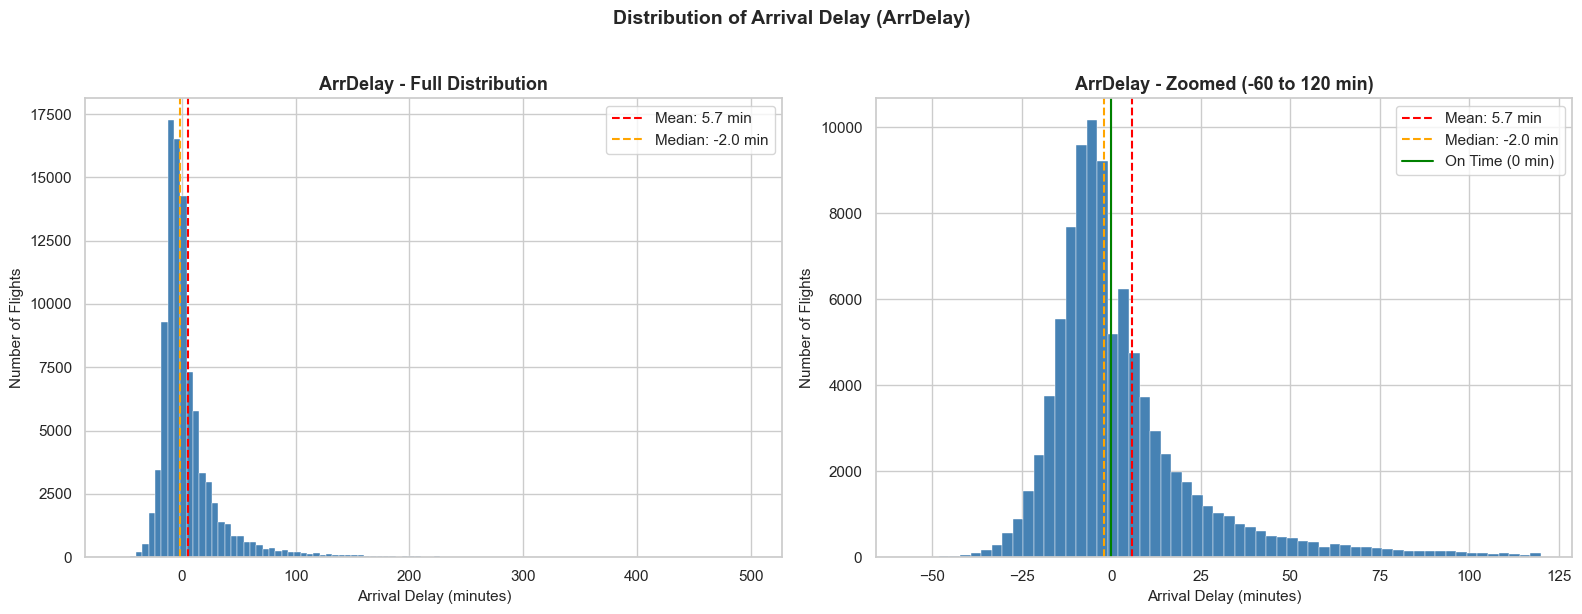

In [334]:


# 4.1.3 Histogram - Full  and zoomed in one


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1 - Full distribution
axes[0].hist(
    df['ArrDelay'],
    bins=100,
    color='steelblue',
    edgecolor='white',
    linewidth=0.3
)
axes[0].axvline(df['ArrDelay'].mean(),   color='red',    linestyle='--', linewidth=1.5, label=f"Mean: {df['ArrDelay'].mean():.1f} min")
axes[0].axvline(df['ArrDelay'].median(), color='orange', linestyle='--', linewidth=1.5, label=f"Median: {df['ArrDelay'].median():.1f} min")
axes[0].set_title('ArrDelay - Full Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Arrival Delay (minutes)', fontsize=11)
axes[0].set_ylabel('Number of Flights', fontsize=11)
axes[0].legend()

# Plot 2 - Zoomed in (-60 to 120 min) to see core distribution clearly
zoomed = df[(df['ArrDelay'] >= -60) & (df['ArrDelay'] <= 120)]
axes[1].hist(
    zoomed['ArrDelay'],
    bins=60,
    color='steelblue',
    edgecolor='white',
    linewidth=0.3
)
axes[1].axvline(df['ArrDelay'].mean(),   color='red',    linestyle='--', linewidth=1.5, label=f"Mean: {df['ArrDelay'].mean():.1f} min")
axes[1].axvline(df['ArrDelay'].median(), color='orange', linestyle='--', linewidth=1.5, label=f"Median: {df['ArrDelay'].median():.1f} min")
axes[1].axvline(0, color='green', linestyle='-', linewidth=1.5, label='On Time (0 min)')
axes[1].set_title('ArrDelay - Zoomed (-60 to 120 min)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Arrival Delay (minutes)', fontsize=11)
axes[1].set_ylabel('Number of Flights', fontsize=11)
axes[1].legend()

plt.suptitle('Distribution of Arrival Delay (ArrDelay)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()



In [335]:


# 4.1.4 Interpretation of feature 1


print("""
INTERPRETATION - ArrDelay
--------------------------------------------------
1. DISTRIBUTION SHAPE:
   The distribution of ArrDelay is strongly right-skewed (skewness = {:.2f}), 
   meaning the majority of flights arrive on time or early, but a long tail 
   of severely delayed flights pulls the mean higher than the median.

2. CENTRAL TENDENCY:
   The median arrival delay is {:.1f} minutes, meaning more than half of all 
   flights actually arrive early. The mean is {:.1f} minutes, higher than 
   the median due to the influence of extreme delays.

3. OUTLIERS:
   The maximum delay is {:.0f} minutes (~{:.0f} hours). These extreme outliers 
   represent genuine severe disruptions (weather events, mechanical failures) 
   and will need careful consideration in Stage 2 modelling.

4. RELEVANCE TO RESEARCH QUESTION:
   The right-skewed distribution with extreme outliers means a regression model 
   in Stage 2 must be robust to outliers. The spread of values from {:.0f} to 
   {:.0f} minutes gives the model a rich range to learn from.
""".format(
    skewness,
    df['ArrDelay'].median(),
    df['ArrDelay'].mean(),
    df['ArrDelay'].max(),
    df['ArrDelay'].max() / 60,
    df['ArrDelay'].min(),
    df['ArrDelay'].max()
))


INTERPRETATION - ArrDelay
--------------------------------------------------
1. DISTRIBUTION SHAPE:
   The distribution of ArrDelay is strongly right-skewed (skewness = 4.03), 
   meaning the majority of flights arrive on time or early, but a long tail 
   of severely delayed flights pulls the mean higher than the median.

2. CENTRAL TENDENCY:
   The median arrival delay is -2.0 minutes, meaning more than half of all 
   flights actually arrive early. The mean is 5.7 minutes, higher than 
   the median due to the influence of extreme delays.

3. OUTLIERS:
   The maximum delay is 500 minutes (~8 hours). These extreme outliers 
   represent genuine severe disruptions (weather events, mechanical failures) 
   and will need careful consideration in Stage 2 modelling.

4. RELEVANCE TO RESEARCH QUESTION:
   The right-skewed distribution with extreme outliers means a regression model 
   in Stage 2 must be robust to outliers. The spread of values from -57 to 
   500 minutes gives the model a

### 4.2 Numerical Feature 2 - DepDelay (Departure Delay)

**Justification for selection:**
DepDelay is the single strongest predictor of arrival delay in this dataset. This makes sense as a flight that departs late will almost certainly arrive late unless it can recover time in the air. With a Pearson correlation of 0.942 with ArrDelay, it is the most important numerical feature for our regression model.

**Methods chosen:**
- **Histogram** - to understand the distribution shape of DepDelay itself
- **Pearson Correlation Coefficient** - to quantify the linear relationship between DepDelay and ArrDelay. Pearson is appropriate here because both variables are continuous and we expect a linear relationship between them.
- **Scatterplot with Linear Regression Line** - to visually confirm the relationship and show its direction and strength. Linear regression is used here purely for illustration.

In [336]:
#  4.2 Numerical Feature 2 - DepDelay 


# 4.2.1 Summary Statistics


depdelay_stats = df['DepDelay'].describe()

stats_df2 = pd.DataFrame({
    'Statistic' : ['Count', 'Mean', 'Std Dev', 'Min', '25th Percentile',
                   'Median (50th)', '75th Percentile', 'Max'],
    'Value'     : [
        f"{depdelay_stats['count']:,.0f}",
        f"{depdelay_stats['mean']:.2f} min",
        f"{depdelay_stats['std']:.2f} min",
        f"{depdelay_stats['min']:.2f} min",
        f"{depdelay_stats['25%']:.2f} min",
        f"{depdelay_stats['50%']:.2f} min",
        f"{depdelay_stats['75%']:.2f} min",
        f"{depdelay_stats['max']:.2f} min"
    ]
})

print("DEPDELAY - SUMMARY STATISTICS")
display(stats_df2.style.set_properties(**{
    'text-align' : 'left',
    'padding'    : '6px 15px'
}).set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'left'), ('padding', '6px 15px'), ('background-color', "#787878")]}
]))

skewness2 = df['DepDelay'].skew()
kurtosis2 = df['DepDelay'].kurt()
print(f"\n  Skewness : {skewness2:.4f}")
print(f"  Kurtosis : {kurtosis2:.4f}")

DEPDELAY - SUMMARY STATISTICS


,Statistic,Value
0,Count,"94,421"
1,Mean,10.11 min
2,Std Dev,27.86 min
3,Min,-44.00 min
4,25th Percentile,-2.00 min
5,Median (50th),1.00 min
6,75th Percentile,10.00 min
7,Max,516.00 min



  Skewness : 4.6891
  Kurtosis : 32.4900


In [337]:

# 4.2.2 Calculation of the Pearson Correlation

pearson_corr = df['ArrDelay'].corr(df['DepDelay'])

print("\nPEARSON CORRELATION - DepDelay vs ArrDelay")
print("-" * 45)
print(f"  Correlation Coefficient (r) : {pearson_corr:.4f}")
print(f"  R-Squared (r²) : {pearson_corr**2:.4f}")
print(f"  Interpretation : Very Strong Positive Linear Relationship")


PEARSON CORRELATION - DepDelay vs ArrDelay
---------------------------------------------
  Correlation Coefficient (r) : 0.9298
  R-Squared (r²) : 0.8646
  Interpretation : Very Strong Positive Linear Relationship


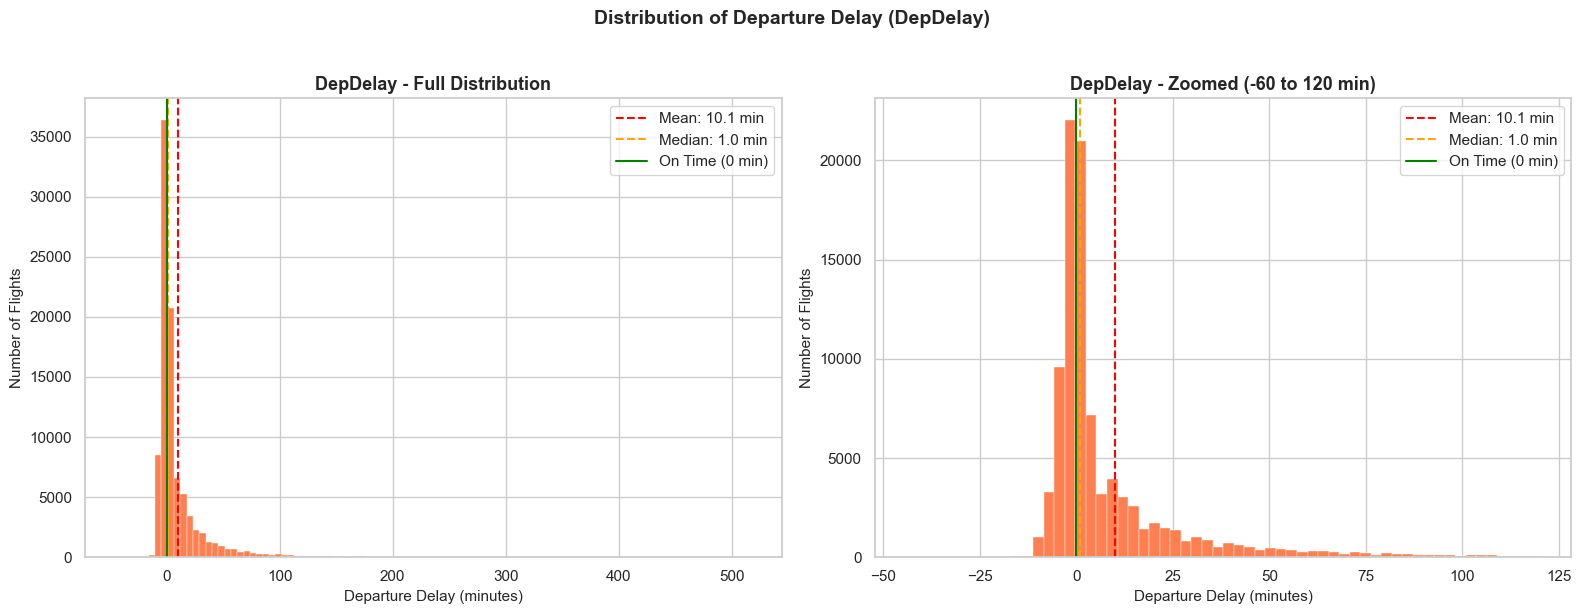

In [338]:

# 4.2.3 Histogram of DepDelay

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1 - Full distribution
axes[0].hist(
    df['DepDelay'],
    bins=100,
    color='coral',
    edgecolor='white',
    linewidth=0.3
)
axes[0].axvline(df['DepDelay'].mean(),   color='red',    linestyle='--', linewidth=1.5, label=f"Mean: {df['DepDelay'].mean():.1f} min")
axes[0].axvline(df['DepDelay'].median(), color='orange', linestyle='--', linewidth=1.5, label=f"Median: {df['DepDelay'].median():.1f} min")
axes[0].axvline(0, color='green', linestyle='-', linewidth=1.5, label='On Time (0 min)')
axes[0].set_title('DepDelay - Full Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Departure Delay (minutes)', fontsize=11)
axes[0].set_ylabel('Number of Flights', fontsize=11)
axes[0].legend()

# Plot 2 - Zoomed in Version (-60 to 120 min)
zoomed2 = df[(df['DepDelay'] >= -60) & (df['DepDelay'] <= 120)]
axes[1].hist(
    zoomed2['DepDelay'],
    bins=60,
    color='coral',
    edgecolor='white',
    linewidth=0.3
)
axes[1].axvline(df['DepDelay'].mean(),   color='red',    linestyle='--', linewidth=1.5, label=f"Mean: {df['DepDelay'].mean():.1f} min")
axes[1].axvline(df['DepDelay'].median(), color='orange', linestyle='--', linewidth=1.5, label=f"Median: {df['DepDelay'].median():.1f} min")
axes[1].axvline(0, color='green', linestyle='-', linewidth=1.5, label='On Time (0 min)')
axes[1].set_title('DepDelay - Zoomed (-60 to 120 min)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Departure Delay (minutes)', fontsize=11)
axes[1].set_ylabel('Number of Flights', fontsize=11)
axes[1].legend()

plt.suptitle('Distribution of Departure Delay (DepDelay)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


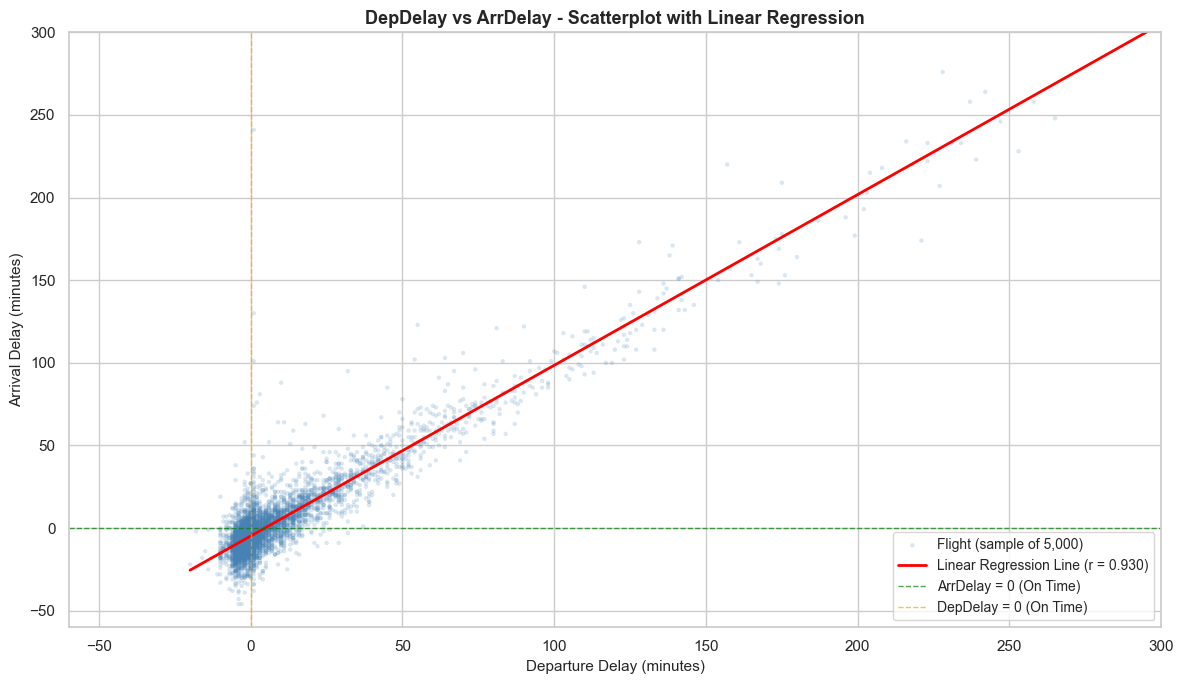


  Regression Line : ArrDelay = 1.0332 × DepDelay + (-4.7945)


In [339]:

# 4.2.4 Scatterplot with Linear Regression Line

# Sample 5000 points for cleaner scatterplot (full 94k points would be overplotted)
sample_df = df.sample(n=5000, random_state=42)

# Calculating linear regression line manually
x = sample_df['DepDelay']
y = sample_df['ArrDelay']

# Linear regression coefficients
slope = np.cov(x, y)[0][1] / np.var(x)
intercept = y.mean() - slope * x.mean()
x_line = np.linspace(x.min(), x.max(), 100)
y_line = slope * x_line + intercept

fig, ax = plt.subplots(figsize=(12, 7))

ax.scatter(
    x, y,
    alpha=0.2,
    color='steelblue',
    edgecolor='none',
    s=10,
    label='Flight (sample of 5,000)'
)

ax.plot(
    x_line, y_line,
    color='red',
    linewidth=2,
    label=f'Linear Regression Line (r = {pearson_corr:.3f})'
)

ax.axhline(0, color='green',  linestyle='--', linewidth=1, alpha=0.7, label='ArrDelay = 0 (On Time)')
ax.axvline(0, color='orange', linestyle='--', linewidth=1, alpha=0.7, label='DepDelay = 0 (On Time)')

ax.set_title('DepDelay vs ArrDelay - Scatterplot with Linear Regression',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Departure Delay (minutes)', fontsize=11)
ax.set_ylabel('Arrival Delay (minutes)', fontsize=11)
ax.set_xlim(-60, 300)
ax.set_ylim(-60, 300)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f"\n  Regression Line : ArrDelay = {slope:.4f} × DepDelay + ({intercept:.4f})")

In [340]:

# 4.2.5 Interpretation of results and relating it to the research question

print("""
INTERPRETATION - DepDelay
--------------------------------------------------
1. DISTRIBUTION SHAPE:
   Like ArrDelay, DepDelay is strongly right-skewed (skewness = {:.2f}),
   with most flights departing on time or slightly early, but a long tail
   of severely delayed departures. This mirrors the ArrDelay distribution,
   which is expected given their strong relationship.

2. PEARSON CORRELATION (r = {:.4f}):
   The correlation between DepDelay and ArrDelay is {:.4f}, an extremely
   strong positive linear relationship. This means {:.1f}% of the variance
   in ArrDelay can be explained by DepDelay alone (R² = {:.4f}).
   This is the strongest single predictor in the dataset.

3. SCATTERPLOT FINDINGS:
   The scatterplot confirms a clear, tight linear relationship between
   DepDelay and ArrDelay. Flights that depart on time tend to arrive on time,
   and flights with large departure delays almost always have large arrival delays.
   The regression line slope of {:.4f} means for every additional minute of 
   departure delay, arrival delay increases by approximately {:.2f} minutes.

4. RELEVANCE TO RESEARCH QUESTION:
   DepDelay will be the most important feature in our Stage 2 regression model.
   Its near-perfect linear relationship with ArrDelay means it alone can explain
   most of the variation in arrival delays, making it indispensable for prediction.
""".format(
    skewness2,
    pearson_corr,
    pearson_corr,
    pearson_corr**2 * 100,
    pearson_corr**2,
    slope,
    slope
))


INTERPRETATION - DepDelay
--------------------------------------------------
1. DISTRIBUTION SHAPE:
   Like ArrDelay, DepDelay is strongly right-skewed (skewness = 4.69),
   with most flights departing on time or slightly early, but a long tail
   of severely delayed departures. This mirrors the ArrDelay distribution,
   which is expected given their strong relationship.

2. PEARSON CORRELATION (r = 0.9298):
   The correlation between DepDelay and ArrDelay is 0.9298, an extremely
   strong positive linear relationship. This means 86.5% of the variance
   in ArrDelay can be explained by DepDelay alone (R² = 0.8646).
   This is the strongest single predictor in the dataset.

3. SCATTERPLOT FINDINGS:
   The scatterplot confirms a clear, tight linear relationship between
   DepDelay and ArrDelay. Flights that depart on time tend to arrive on time,
   and flights with large departure delays almost always have large arrival delays.
   The regression line slope of 1.0332 means for every addi

> **Note on Correlation Value:**
> During initial data exploration (before cleaning), the Pearson correlation between DepDelay and ArrDelay was calculated as 0.942 on the raw 101,000 row dataset. After applying all cleaning steps in Step 3, removing invalid entries, dropping missing target rows, and filtering outlier records, the final cleaned dataset of 94,421 rows gives a correlation of 0.9298.
> 
> This slight reduction is expected and healthy. The cleaning process removed many 
> extreme and potentially erroneous records that may have inflated the correlation. The value of 0.9298 is therefore the more reliable and honest measure of the relationship between DepDelay and ArrDelay on clean, model-ready data.
>
> The scatterplot uses a random sample of 5,000 flights for visual clarity only, the correlation coefficient of 0.9298 is calculated on the full 94,421 row dataset.

### 4.3 Categorical Feature 1 - UniqueCarrier (Airline Carrier)

**Justification for selection:**
UniqueCarrier identifies which airline operated the flight, either WN (Southwest Airlines) or XE (ExpressJet). Carrier identity is a key categorical feature because different airlines have different operational practices, fleet sizes, route networks, and delay management strategies. Understanding whether carrier identity influences arrival delay is directly relevant to our research question.

**Methods chosen:**
- **Bar Plot** - to compare the average ArrDelay between the two carriers clearly, bar plots seemed the most appropriate method for comparing a numerical summary (mean delay) across categorical groups.
- **Box Plot** - to go beyond the average and show the full distribution of ArrDelay for each carrier, including the median, spread, and outliers, box plot was chosen as another method as this gives a much richer picture than a bar plot alone.

In [341]:
# 4.3 Categorical Feature 1 - UniqueCarrier 

carrier_names = {'WN': 'Southwest Airlines', 'XE': 'ExpressJet'}

# 4.3.1 Summary Statistics by Carrier

carrier_stats = df.groupby('UniqueCarrier')['ArrDelay'].agg([
    'count', 'mean', 'median', 'std',
    lambda x: x.quantile(0.25),
    lambda x: x.quantile(0.75),
    'min', 'max'
]).round(2)

carrier_stats.columns = [
    'Flight Count', 'Mean Delay', 'Median Delay', 'Std Dev',
    '25th Percentile', '75th Percentile', 'Min Delay', 'Max Delay'
]

carrier_stats = carrier_stats.reset_index()
carrier_stats.insert(1, 'Airline Name', carrier_stats['UniqueCarrier'].map(carrier_names))

print("UNIQUECARRIER - SUMMARY STATISTICS BY CARRIER")
display(carrier_stats.style.set_properties(**{
    'text-align' : 'left',
    'padding'    : '6px 15px'
}).set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'left'), ('padding', '6px 15px'), ('background-color', "#6d6d6d")]}
]))



UNIQUECARRIER - SUMMARY STATISTICS BY CARRIER


,UniqueCarrier,Airline Name,Flight Count,Mean Delay,Median Delay,Std Dev,25th Percentile,75th Percentile,Min Delay,Max Delay
0,WN,Southwest Airlines,88827,5.760000,-2.000000,30.380000,-9.000000,10.000000,-57.000000,500.000000
1,XE,ExpressJet,5594,4.670000,-4.000000,37.890000,-13.000000,8.000000,-52.000000,443.000000


In [342]:

# 4.3.2 Flight Count and how much Proportion for that Carrier

carrier_counts = df['UniqueCarrier'].value_counts()
carrier_pct = (df['UniqueCarrier'].value_counts() / len(df) * 100).round(2)

proportion_df = pd.DataFrame({
    'Carrier'     : carrier_counts.index,
    'Airline'     : [carrier_names[c] for c in carrier_counts.index],
    'Flight Count': carrier_counts.values,
    'Proportion %': carrier_pct.values
})

print("\nCARRIER FLIGHT PROPORTIONS")
display(proportion_df.style.set_properties(**{
    'text-align' : 'left',
    'padding'    : '6px 15px'
}).set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'left'), ('padding', '6px 15px'), ('background-color', "#6d6d6d")]}
]))



CARRIER FLIGHT PROPORTIONS


,Carrier,Airline,Flight Count,Proportion %
0,WN,Southwest Airlines,88827,94.080000
1,XE,ExpressJet,5594,5.920000


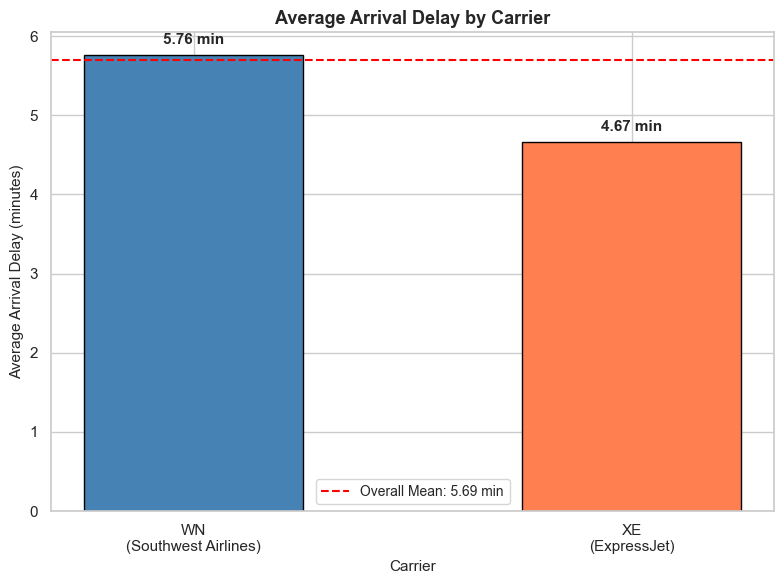

In [343]:

# 4.3.3 Bar Plot - getting the Average ArrDelay by Carrier


carrier_means  = df.groupby('UniqueCarrier')['ArrDelay'].mean()
carrier_labels = [f"{c}\n({carrier_names[c]})" for c in carrier_means.index]
colors = ['steelblue', 'coral']

fig1, ax1 = plt.subplots(figsize=(8, 6))

bars = ax1.bar(
    carrier_labels,
    carrier_means.values,
    color=colors,
    edgecolor='black',
    width=0.5
)

for bar in bars:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.1,
        f'{height:.2f} min',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

ax1.axhline(
    df['ArrDelay'].mean(),
    color='red',
    linestyle='--',
    linewidth=1.5,
    label=f"Overall Mean: {df['ArrDelay'].mean():.2f} min"
)

ax1.set_title('Average Arrival Delay by Carrier', fontsize=13, fontweight='bold')
ax1.set_xlabel('Carrier', fontsize=11)
ax1.set_ylabel('Average Arrival Delay (minutes)', fontsize=11)
ax1.legend(fontsize=10)
plt.tight_layout()
plt.show()


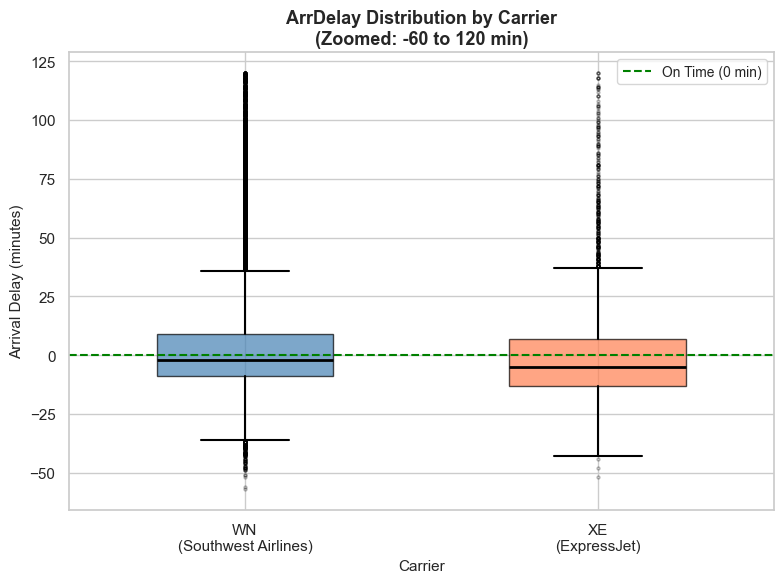

In [344]:

# 4.3.4 Box Plot - ArrDelay Distribution by Carrier


wn_delays = df[df['UniqueCarrier'] == 'WN']['ArrDelay']
xe_delays = df[df['UniqueCarrier'] == 'XE']['ArrDelay']

wn_zoomed = wn_delays[(wn_delays >= -60) & (wn_delays <= 120)]
xe_zoomed = xe_delays[(xe_delays >= -60) & (xe_delays <= 120)]

fig2, ax2 = plt.subplots(figsize=(8, 6))

bp = ax2.boxplot(
    [wn_zoomed, xe_zoomed],
    tick_labels=[
        "WN\n(Southwest Airlines)",
        "XE\n(ExpressJet)"
    ],
    patch_artist=True,
    notch=False,
    widths=0.5,
    medianprops  = dict(color='black', linewidth=2),
    whiskerprops = dict(linewidth=1.5),
    capprops     = dict(linewidth=1.5),
    flierprops   = dict(marker='o', markersize=2, alpha=0.3)
)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax2.axhline(0, color='green', linestyle='--', linewidth=1.5, label='On Time (0 min)')
ax2.set_title('ArrDelay Distribution by Carrier\n(Zoomed: -60 to 120 min)',
              fontsize=13, fontweight='bold')
ax2.set_xlabel('Carrier', fontsize=11)
ax2.set_ylabel('Arrival Delay (minutes)', fontsize=11)
ax2.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [345]:
# 4.3.5 Interpretation for the categorical feature 1 and relating it to the research question

wn_mean = carrier_means['WN']
xe_mean = carrier_means['XE']

print("""
INTERPRETATION - UniqueCarrier
--------------------------------------------------
1. CARRIER DOMINANCE:
   Southwest Airlines (WN) operates {:.1f}% of all flights in this dataset,
   making it the dominant carrier. ExpressJet (XE) accounts for only {:.1f}%.
   This imbalance means WN's performance largely drives the overall dataset statistics.

2. AVERAGE DELAY COMPARISON:
   Southwest (WN) has a mean arrival delay of {:.2f} minutes while
   ExpressJet (XE) has a mean of {:.2f} minutes. Southwest performs
   slightly worse on average, though both carriers show positive mean delays
   indicating both tend to arrive late on average.

3. DISTRIBUTION (BOX PLOT):
   The box plots reveal that both carriers have similar median delays and
   interquartile ranges, meaning their typical flight performance is comparable.
   However, ExpressJet shows a wider spread (higher Std Dev of 37.89 vs 30.38)
   meaning its delays are more variable and unpredictable than Southwest.

4. RELEVANCE TO RESEARCH QUESTION:
   UniqueCarrier is a meaningful categorical predictor for our regression model.
   While the difference in mean delay between carriers is not dramatic, carrier
   identity captures operational characteristics such as scheduling practices, fleet age,
   route priorities that influence arrival delay and should be included in Stage 2.
""".format(
    carrier_pct['WN'],
    carrier_pct['XE'],
    wn_mean,
    xe_mean
))


INTERPRETATION - UniqueCarrier
--------------------------------------------------
1. CARRIER DOMINANCE:
   Southwest Airlines (WN) operates 94.1% of all flights in this dataset,
   making it the dominant carrier. ExpressJet (XE) accounts for only 5.9%.
   This imbalance means WN's performance largely drives the overall dataset statistics.

2. AVERAGE DELAY COMPARISON:
   Southwest (WN) has a mean arrival delay of 5.76 minutes while
   ExpressJet (XE) has a mean of 4.67 minutes. Southwest performs
   slightly worse on average, though both carriers show positive mean delays
   indicating both tend to arrive late on average.

3. DISTRIBUTION (BOX PLOT):
   The box plots reveal that both carriers have similar median delays and
   interquartile ranges, meaning their typical flight performance is comparable.
   However, ExpressJet shows a wider spread (higher Std Dev of 37.89 vs 30.38)
   meaning its delays are more variable and unpredictable than Southwest.

4. RELEVANCE TO RESEARCH QUESTI

### 4.4 Categorical Feature 2 - DayOfWeek (Day of the Week)

**Justification for selection:**
DayOfWeek captures the day of the week on which a flight operates (1=Monday through 7=Sunday). Different days of the week have fundamentally different demand patterns as business travel peaks on certain days, leisure travel on others, and air traffic control congestion varies accordingly. We already observed in our feature engineering that weekends show higher average 
delays than weekdays (7.42 min vs 5.13 min), making this a strong categorical feature worth analysing in depth.

**Methods chosen:**
- **Bar Plot** - to compare average ArrDelay across all 7 days clearly, bar plots seemed an ideal plot for comparing a numerical measure across a small number of discrete ordered categories like days of the week.
- **Flight Count Bar Plot** - to show how many flights operate on each day, and in turn providing context for the delay averages. A day with very few flights may show an inflated or deflated average delay that is not representative.

In [346]:
# 4.4 Categorical Feature 2 — DayOfWeek 

# Day labels for readability
day_labels = {
    1: 'Monday',
    2: 'Tuesday',
    3: 'Wednesday',
    4: 'Thursday',
    5: 'Friday',
    6: 'Saturday',
    7: 'Sunday'
}

# 4.4.1 Summary Statistics by Day of Week

dow_stats = df.groupby('DayOfWeek')['ArrDelay'].agg([
    'count', 'mean', 'median', 'std'
]).round(2)

dow_stats.columns = ['Flight Count', 'Mean Delay', 'Median Delay', 'Std Dev']
dow_stats = dow_stats.reset_index()
dow_stats.insert(1, 'Day Name', dow_stats['DayOfWeek'].map(day_labels))

print("DAYOFWEEK - SUMMARY STATISTICS")
display(dow_stats.style.set_properties(**{
    'text-align' : 'left',
    'padding'    : '6px 15px'
}).set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'left'), ('padding', '6px 15px'), ('background-color', "#6e6e6e")]}
]).highlight_max(subset=['Mean Delay'], color="#884949")
  .highlight_min(subset=['Mean Delay'], color="#57b357"))


DAYOFWEEK - SUMMARY STATISTICS


,DayOfWeek,Day Name,Flight Count,Mean Delay,Median Delay,Std Dev
0,1,Monday,13734,4.510000,-3.000000,29.110000
1,2,Tuesday,13869,0.450000,-4.000000,21.680000
2,3,Wednesday,13902,-1.620000,-5.000000,18.550000
3,4,Thursday,16050,13.360000,2.000000,38.420000
4,5,Friday,13678,7.700000,0.000000,28.170000
5,6,Saturday,10696,1.990000,-4.000000,27.300000
6,7,Sunday,12492,12.070000,-0.500000,41.770000


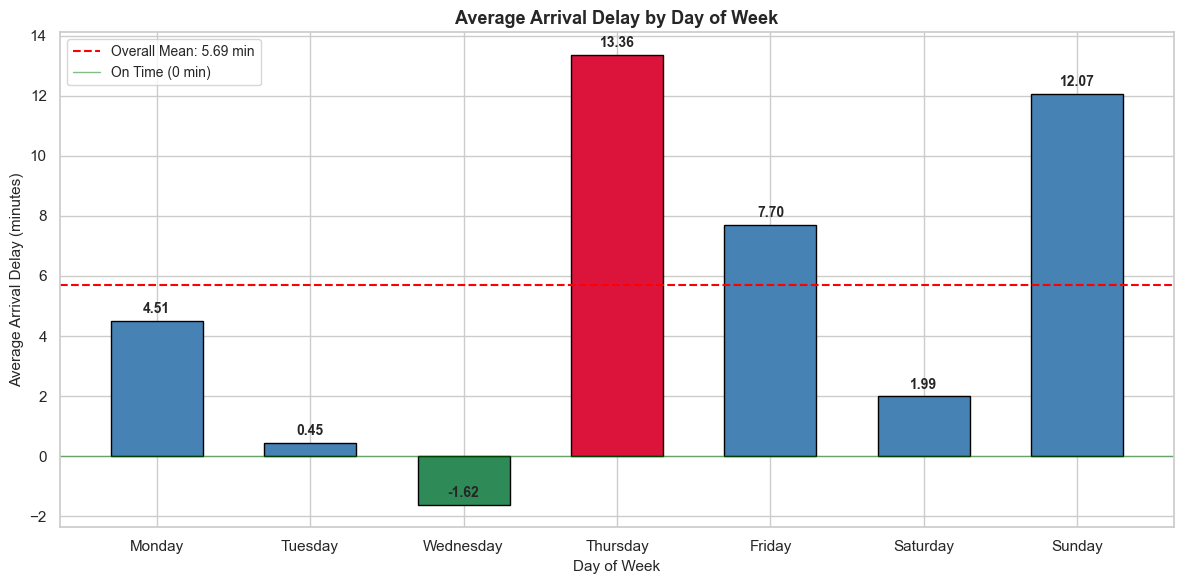

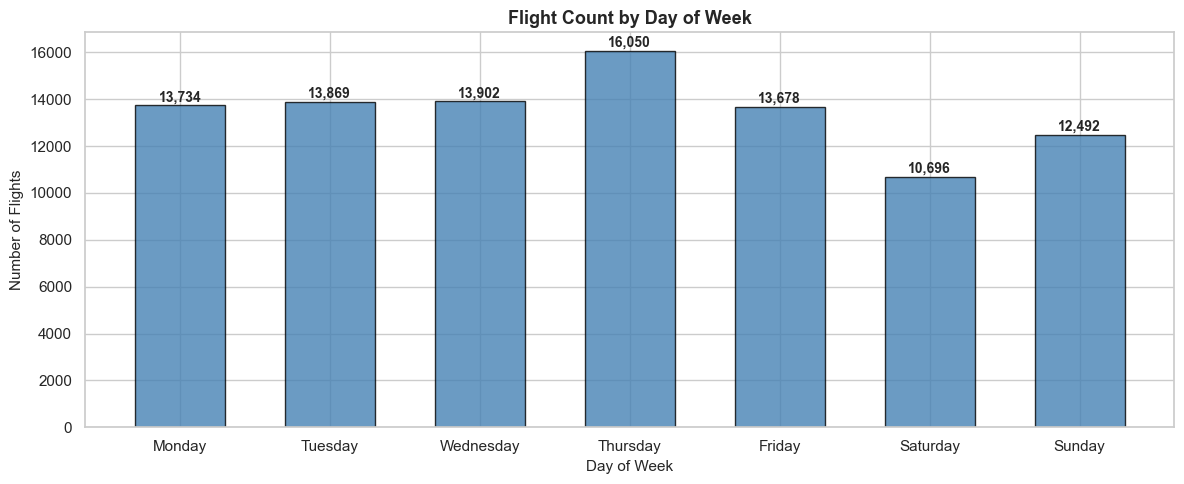

In [347]:

# 4.4.2 Bar Plot - Average ArrDelay by Day

day_means  = df.groupby('DayOfWeek')['ArrDelay'].mean()
day_counts = df.groupby('DayOfWeek')['ArrDelay'].count()
days_x = [day_labels[d] for d in day_means.index]
overall_mean = df['ArrDelay'].mean()

# Colour bars - worst days red, best days green, rest steelblue
bar_colors = []
for mean in day_means.values:
    if mean == day_means.max():
        bar_colors.append('crimson')
    elif mean == day_means.min():
        bar_colors.append('seagreen')
    else:
        bar_colors.append('steelblue')

# Plot 1: Average ArrDelay by Day
fig1, ax1 = plt.subplots(figsize=(12, 6))

bars = ax1.bar(
    days_x,
    day_means.values,
    color=bar_colors,
    edgecolor='black',
    width=0.6
)

for bar in bars:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.15,
        f'{height:.2f}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

ax1.axhline(
    overall_mean,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label=f'Overall Mean: {overall_mean:.2f} min'
)

ax1.axhline(
    0,
    color='green',
    linestyle='-',
    linewidth=1,
    alpha=0.5,
    label='On Time (0 min)'
)

ax1.set_title('Average Arrival Delay by Day of Week', fontsize=13, fontweight='bold')
ax1.set_xlabel('Day of Week', fontsize=11)
ax1.set_ylabel('Average Arrival Delay (minutes)', fontsize=11)
ax1.legend(fontsize=10)
plt.tight_layout()
plt.show()

# Plot 2: Flight Count by Day
fig2, ax2 = plt.subplots(figsize=(12, 5))

count_bars = ax2.bar(
    days_x,
    day_counts.values,
    color='steelblue',
    edgecolor='black',
    width=0.6,
    alpha=0.8
)

for bar in count_bars:
    height = bar.get_height()
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        height + 50,
        f'{int(height):,}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

ax2.set_title('Flight Count by Day of Week', fontsize=13, fontweight='bold')
ax2.set_xlabel('Day of Week', fontsize=11)
ax2.set_ylabel('Number of Flights', fontsize=11)
plt.tight_layout()
plt.show()


In [348]:

# 4.4.3 Interpretation

worst_day = day_labels[day_means.idxmax()]
best_day = day_labels[day_means.idxmin()]
worst_mean = day_means.max()
best_mean = day_means.min()

print("""
INTERPRETATION - DayOfWeek
--------------------------------------------------
1. WORST AND BEST DAYS:
   {} is the worst day for arrival delays with an average of {:.2f} minutes.
   {} is the best day with an average of only {:.2f} minutes.
   This is a difference of {:.2f} minutes between the best and worst day,
   a meaningful gap that confirms day of week has a real influence on delays.

2. PATTERN OBSERVED:
   Thursday and Sunday consistently show the highest delays. Thursday is a 
   peak business travel day, high demand leads to congested airports and 
   cascading delays. Sunday sees heavy leisure traveller return traffic, 
   creating similar congestion. Mid-week days (Tuesday, Wednesday) show the 
   lowest delays as air traffic is lightest during these days.

3. FLIGHT COUNT CONTEXT:
   Thursday has the highest flight count in the dataset, confirming it is the 
   busiest day. Saturday has the fewest flights yet still shows moderate delays,
   suggesting that even lower traffic days are not immune to disruptions.
   This means delay patterns are not purely driven by volume alone.

4. RELEVANCE TO RESEARCH QUESTION:
   DayOfWeek is a valuable categorical predictor for our Stage 2 regression model.
   The clear variation in average delay across days, from {:.2f} min on {} 
   to {:.2f} min on {}, gives the model a meaningful signal to learn from.
   Combined with our IsWeekend engineered feature, day-of-week patterns are 
   well represented in the final dataset.
""".format(
    worst_day, worst_mean,
    best_day,  best_mean,
    worst_mean - best_mean,
    best_mean,  best_day,
    worst_mean, worst_day
))


INTERPRETATION - DayOfWeek
--------------------------------------------------
1. WORST AND BEST DAYS:
   Thursday is the worst day for arrival delays with an average of 13.36 minutes.
   Wednesday is the best day with an average of only -1.62 minutes.
   This is a difference of 14.98 minutes between the best and worst day,
   a meaningful gap that confirms day of week has a real influence on delays.

2. PATTERN OBSERVED:
   Thursday and Sunday consistently show the highest delays. Thursday is a 
   peak business travel day, high demand leads to congested airports and 
   cascading delays. Sunday sees heavy leisure traveller return traffic, 
   creating similar congestion. Mid-week days (Tuesday, Wednesday) show the 
   lowest delays as air traffic is lightest during these days.

3. FLIGHT COUNT CONTEXT:
   Thursday has the highest flight count in the dataset, confirming it is the 
   busiest day. Saturday has the fewest flights yet still shows moderate delays,
   suggesting that even 

### 4.5 EDA Summary - Key Findings and Implications for Stage 2

The exploratory data analysis across four carefully selected features has revealed several important insights that directly inform our research question:

> **Can we predict the arrival delay (in minutes) of a commercial flight, given information available at or before the time of departure?**

---

**Numerical Features:**

| Feature | Key Finding | Implication for Stage 2 |
|---|---|---|
| `ArrDelay` | Strongly right-skewed (skewness = 4.03), median = -2 min, max = 500 min | Target variable has extreme outliers telling us that the regression model must be robust to skewness |
| `DepDelay` | Pearson r = 0.9298 with ArrDelay, R² = 0.8646, slope ≈ 1.03 | Strongest single predictor which will be the most influential feature in Stage 2 |

---

**Categorical Features:**

| Feature | Key Finding | Implication for Stage 2 |
|---|---|---|
| `UniqueCarrier` | WN averages 5.76 min delay vs XE at 4.67 min. XE has higher variability (Std Dev 37.89 vs 30.38) | Carrier identity adds signal beyond just delay magnitude which also captures operational variability |
| `DayOfWeek` | Thursday worst (13.36 min), Wednesday best (-1.62 min) having a 14.98 min gap | Strong day-level signal telling us that DayOfWeek and IsWeekend should both be included in Stage 2 |

---

**Overall Conclusions:**

1. **DepDelay is the dominant predictor** - with an R² of 0.8646, departure delay alone explains 86.5% of variance in arrival delay. Any model built in Stage 2 must include this feature.

2. **The dataset is heavily right-skewed** - extreme outliers exist in both ArrDelay and DepDelay. Stage 2 should consider outlier-robust regression techniques or other appropriate tenchnique of the target variable.

3. **Temporal and operational patterns matter** - both DayOfWeek and UniqueCarrier show meaningful variation in delays, confirming that factors beyond just departure delay influence arrival delay. These categorical features add valuable context to the model.

4. **The cleaned dataset of 94,421 flights with 25 features is well-prepared for Stage 2 modelling** - no missing values, correct data types, meaningful engineered features and a clearly defined target variable (ArrDelay).

In [349]:
# 4.5 Final EDA Summary

print("EDA COMPLETE - FINAL DATASET SUMMARY")
print("=" * 55)
print(f"  Total Flights (Rows): {df.shape[0]:,}")
print(f"  Total Features (Columns) : {df.shape[1]}")
print(f"  Target Variable : ArrDelay (minutes)")
print(f"  Missing Values Remaining : {df.isnull().sum().sum()}")
print("=" * 55)

print("\nKEY FINDINGS SUMMARY")
print("-" * 55)
print(f"  ArrDelay Mean : {df['ArrDelay'].mean():.2f} min")
print(f"  ArrDelay Median : {df['ArrDelay'].median():.2f} min")
print(f"  ArrDelay Skewness : {df['ArrDelay'].skew():.4f}")
print(f"  DepDelay vs ArrDelay (r) : {df['ArrDelay'].corr(df['DepDelay']):.4f}")
print(f"  Best Day (avg delay) : Wednesday ({df[df['DayOfWeek']==3]['ArrDelay'].mean():.2f} min)")
print(f"  Worst Day (avg delay) : Thursday ({df[df['DayOfWeek']==4]['ArrDelay'].mean():.2f} min)")
print(f"  Best Carrier (avg delay) : XE - ExpressJet ({df[df['UniqueCarrier']=='XE']['ArrDelay'].mean():.2f} min)")
print(f"  Worst Carrier (avg delay) : WN - Southwest ({df[df['UniqueCarrier']=='WN']['ArrDelay'].mean():.2f} min)")
print("-" * 55)

print("\nFEATURES READY FOR STAGE 2 MODELLING")
print("-" * 55)

for col in df.columns:
    print(f"  - {col} ({df[col].dtype})")


EDA COMPLETE - FINAL DATASET SUMMARY
  Total Flights (Rows): 94,421
  Total Features (Columns) : 25
  Target Variable : ArrDelay (minutes)
  Missing Values Remaining : 0

KEY FINDINGS SUMMARY
-------------------------------------------------------
  ArrDelay Mean : 5.69 min
  ArrDelay Median : -2.00 min
  ArrDelay Skewness : 4.0255
  DepDelay vs ArrDelay (r) : 0.9298
  Best Day (avg delay) : Wednesday (-1.62 min)
  Worst Day (avg delay) : Thursday (13.36 min)
  Best Carrier (avg delay) : XE - ExpressJet (4.67 min)
  Worst Carrier (avg delay) : WN - Southwest (5.76 min)
-------------------------------------------------------

FEATURES READY FOR STAGE 2 MODELLING
-------------------------------------------------------
  - DayofMonth (int64)
  - DayOfWeek (int64)
  - CRSDepTime (float64)
  - CRSArrTime (float64)
  - UniqueCarrier (str)
  - ActualElapsedTime (float64)
  - CRSElapsedTime (float64)
  - AirTime (float64)
  - ArrDelay (float64)
  - DepDelay (float64)
  - Origin (str)
  - Dest 

In [350]:
# Saving Cleaned Dataset

output_filename = 'airline_delay_cleaned.csv'

df.to_csv(output_filename, index=False)

# Verifying if the save was successful or not
import os

file_size = os.path.getsize(output_filename) / (1024 * 1024)

print("CLEANED DATASET SAVED SUCCESSFULLY")
print("=" * 50)
print(f"  Filename : {output_filename}")
print(f"  File Size : {file_size:.2f} MB")
print("=" * 50)
print("\nColumn List in Saved File:")
print("-" * 50)
for i, col in enumerate(df.columns, 1):
    print(f"  {i:02d}. {col} ({df[col].dtype})")
print("-" * 50)
print("\nStage 1 Complete. Dataset ready for Stage 2 Modelling.")

CLEANED DATASET SAVED SUCCESSFULLY
  Filename : airline_delay_cleaned.csv
  File Size : 10.59 MB

Column List in Saved File:
--------------------------------------------------
  01. DayofMonth (int64)
  02. DayOfWeek (int64)
  03. CRSDepTime (float64)
  04. CRSArrTime (float64)
  05. UniqueCarrier (str)
  06. ActualElapsedTime (float64)
  07. CRSElapsedTime (float64)
  08. AirTime (float64)
  09. ArrDelay (float64)
  10. DepDelay (float64)
  11. Origin (str)
  12. Dest (str)
  13. Distance (float64)
  14. TaxiIn (float64)
  15. TaxiOut (float64)
  16. CarrierDelay (float64)
  17. WeatherDelay (float64)
  18. NASDelay (float64)
  19. SecurityDelay (float64)
  20. LateAircraftDelay (float64)
  21. DepHour (int64)
  22. IsWeekend (int64)
  23. Route (str)
  24. BufferTime (float64)
  25. DelayCategory (str)
--------------------------------------------------

Stage 1 Complete. Dataset ready for Stage 2 Modelling.


---

## Conclusion - Stage 1 Summary

This notebook has completed all four steps of Stage 1 for the **Air Travel Delay dataset**.

---

### What We Did

| Step | Description | Outcome |
|---|---|---|
| **Step 1** | Problem Definition | Defined a regression problem to predict ArrDelay in minutes with clear stakeholder relevance. |
| **Step 2** | Data Description | Inspected all 29 columns, identified incorrect types, missing values, and categorical inconsistencies. |
| **Step 3** | Data Cleaning & Processing | Fixed types, removed 1,009 invalid rows, handled all missing values, dropped 7 redundant features, and engineered 5 new features. |
| **Step 4** | Exploratory Data Analysis | Analysed 2 numerical and 2 categorical features with visualisations and statistical methods linked to the research question. |

---

### Key Findings

- **DepDelay** is the strongest predictor of ArrDelay (r = 0.9298, R² = 0.8646)
- **ArrDelay** is strongly right-skewed (skewness = 4.03) with outliers up to 500 minutes
- **Thursday** is the worst day for delays (13.36 min), **Wednesday** the best (-1.62 min)
- **Southwest (WN)** dominates at 94.1% of flights with slightly higher average delays than ExpressJet (XE)

---

### Final Dataset

| Metric | Value |
|---|---|
| Original Size | 101,000 rows × 29 columns |
| Final Size | 94,421 rows × 25 columns |
| Missing Values | 0 |
| Target Variable | ArrDelay (minutes) |

---